In [ ]:
# Si necesitan instalar algunos paquetes
#!pip install scipy
#!pip install pandas
#!pip install seaborn
#!pip install scikit-learn

In [1]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

# Para clustering
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler 
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# Para componentes principales
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Introducción: Fútbol analytics

Esto es un pantallazo del TP 2 del año pasado. Tenemos datos de futbolistas de las grandes ligas de Europa, y queremos visualizar los datos, para ver si podemos identificar grupos de jugadores.

In [3]:
data = pd.read_csv("futbolistas.csv")
data

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,PrgDistCarry/90,ProgCarry/90,CarryIntoThird/90,CarryIntoBox/90,Miscontrol/90,Dispossessed/90,PassTarget/90,PassesReceived/90,PassRec%,ProgPassReceived/90
0,Patrick van Aanholt,nl NED,DF,Crystal Palace,eng Premier League,29.0,1990.0,22,20,1777,...,96.8,5.79,1.52,0.46,0.66,0.81,42.3,39.3,92.8,2.34
1,Yunis Abdelhamid,ma MAR,DF,Reims,fr Ligue 1,32.0,1987.0,33,33,2889,...,130.5,1.81,0.25,0.03,0.25,0.47,43.8,42.5,97.0,0.22
2,Pape Abou Cisse,sn SEN,DF,Saint-Étienne,fr Ligue 1,24.0,1995.0,14,14,1260,...,117.9,1.14,0.07,0.00,0.14,0.07,33.7,32.9,97.7,0.00
3,David Abraham,ar ARG,DF,Eint Frankfurt,de Bundesliga,34.0,1986.0,14,14,1222,...,92.7,3.24,0.66,0.00,0.22,0.00,34.8,33.4,96.0,0.59
4,Francesco Acerbi,it ITA,DF,Lazio,it Serie A,32.0,1988.0,32,32,2813,...,166.3,3.71,1.02,0.03,0.45,0.26,50.9,49.5,97.3,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1897,Reinhold Yabo,de GER,"MF,FW",Arminia,de Bundesliga,28.0,1992.0,13,8,647,...,76.3,3.47,1.39,0.42,0.97,0.97,31.1,21.0,67.4,2.78
1898,Amin Younes,de GER,"MF,FW",Eint Frankfurt,de Bundesliga,26.0,1993.0,26,16,1391,...,138.4,8.71,2.00,1.03,2.19,2.58,58.1,44.3,76.2,8.26
1899,Mattia Zaccagni,it ITA,"MF,FW",Hellas Verona,it Serie A,25.0,1995.0,36,33,2609,...,141.8,7.45,2.52,1.10,2.31,2.86,49.2,35.5,72.1,8.21
1900,Arber Zeneli,xk KVX,"MF,FW",Reims,fr Ligue 1,25.0,1995.0,28,14,1289,...,102.0,5.24,1.40,1.12,2.94,2.45,40.3,28.0,69.3,6.15


In [4]:
# Nos quedamos con variables numéricas
data_num = data[
    data.columns[11:]
]  # Nos quedamos con las columnas a partir de Ast/90 inclusive
data_num

,Ast/90,npG/90,npG+A/90,xA/90,npxG/90,npxG+xA/90,Shots/90,SoTs/90,FKSht/90,np:G-xG,...,PrgDistCarry/90,ProgCarry/90,CarryIntoThird/90,CarryIntoBox/90,Miscontrol/90,Dispossessed/90,PassTarget/90,PassesReceived/90,PassRec%,ProgPassReceived/90
0,0.05,0.00,0.05,0.04,0.06,0.10,0.91,0.30,0.15,-0.06,...,96.8,5.79,1.52,0.46,0.66,0.81,42.3,39.3,92.8,2.34
1,0.00,0.09,0.09,0.01,0.05,0.06,0.47,0.16,0.00,0.04,...,130.5,1.81,0.25,0.03,0.25,0.47,43.8,42.5,97.0,0.22
2,0.00,0.00,0.00,0.00,0.08,0.09,0.93,0.21,0.00,-0.09,...,117.9,1.14,0.07,0.00,0.14,0.07,33.7,32.9,97.7,0.00
3,0.00,0.07,0.07,0.03,0.05,0.08,0.66,0.15,0.00,0.02,...,92.7,3.24,0.66,0.00,0.22,0.00,34.8,33.4,96.0,0.59
4,0.03,0.00,0.03,0.03,0.03,0.06,0.26,0.00,0.00,-0.03,...,166.3,3.71,1.02,0.03,0.45,0.26,50.9,49.5,97.3,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1897,0.00,0.14,0.14,0.00,0.09,0.09,1.11,0.14,0.00,0.06,...,76.3,3.47,1.39,0.42,0.97,0.97,31.1,21.0,67.4,2.78
1898,0.19,0.19,0.39,0.11,0.22,0.33,2.13,0.84,0.00,-0.03,...,138.4,8.71,2.00,1.03,2.19,2.58,58.1,44.3,76.2,8.26
1899,0.17,0.14,0.31,0.18,0.11,0.28,1.03,0.41,0.03,0.03,...,141.8,7.45,2.52,1.10,2.31,2.86,49.2,35.5,72.1,8.21
1900,0.21,0.21,0.42,0.14,0.12,0.26,1.47,0.63,0.07,0.09,...,102.0,5.24,1.40,1.12,2.94,2.45,40.3,28.0,69.3,6.15


In [5]:
# Imprimimos todos los nombres de columnas
for item in data_num.columns:
    print(item)

Ast/90
npG/90
npG+A/90
xA/90
npxG/90
npxG+xA/90
Shots/90
SoTs/90
FKSht/90
np:G-xG
PassCmp/90
PassAtt/90
PassCmp%
TotDistPass/90
PrgDistPass/90
ShortCmp/90
ShortAtt/90
ShortCmp%
MedCmp/90
MedAtt/90
MedCmp%
LongCmp/90
LongAtt/90
LongCmp%
KeyPass/90
PassIntoThird/90
PassIntoBox/90
CrossIntoBox/90
ProgPass/90
LivePassAtt/90
DeadPassAtt/90
FKPassAtt/90
TBCmp/90
PassUnderPress/90
Switches/90
Crosses/90
GroundPass/90
LowPass/90
HighPass/90
LeftPass/90
RightPass/90
HeadPass/90
ThrowPass/90
OtherPartPass/90
OffsidePass/90
OutOBPass/90
PassesInt/90
PassesBlk/90
SCA/90
PassLiveSCA/90
PassDeadSCA/90
DribSCA/90
ShSCA/90
FoulSCA/90
DefSCA/90
GCA/90
PassLiveGCA/90
PassDeadGCA/90
DribGCA/90
ShGCA/90
FoulGCA/90
DefGCA/90
TklAtt/90
TklW/90
Def 3rdTkl/90
Mid 3rdTkl/90
Att 3rdTkl/90
TklvDribW/90
TklvDribAtt/90
Tkl%vDrib
DribPast/90
PressAtt/90
SuccPress/90
PressSucc%
Def 3rdPress/90
Mid 3rdPress/90
Att 3rdPress/90
Blocks/90
ShotBlocks/90
PassBlk/90
Interceptions/90
Clearances/90
ErrToShot/90
Touches/90
De

### a) Gráfico de dispersión
Elegimos dos variables de los datos y realizamos un gráfico de dispersión de una en función de la otra para el total de los registros.

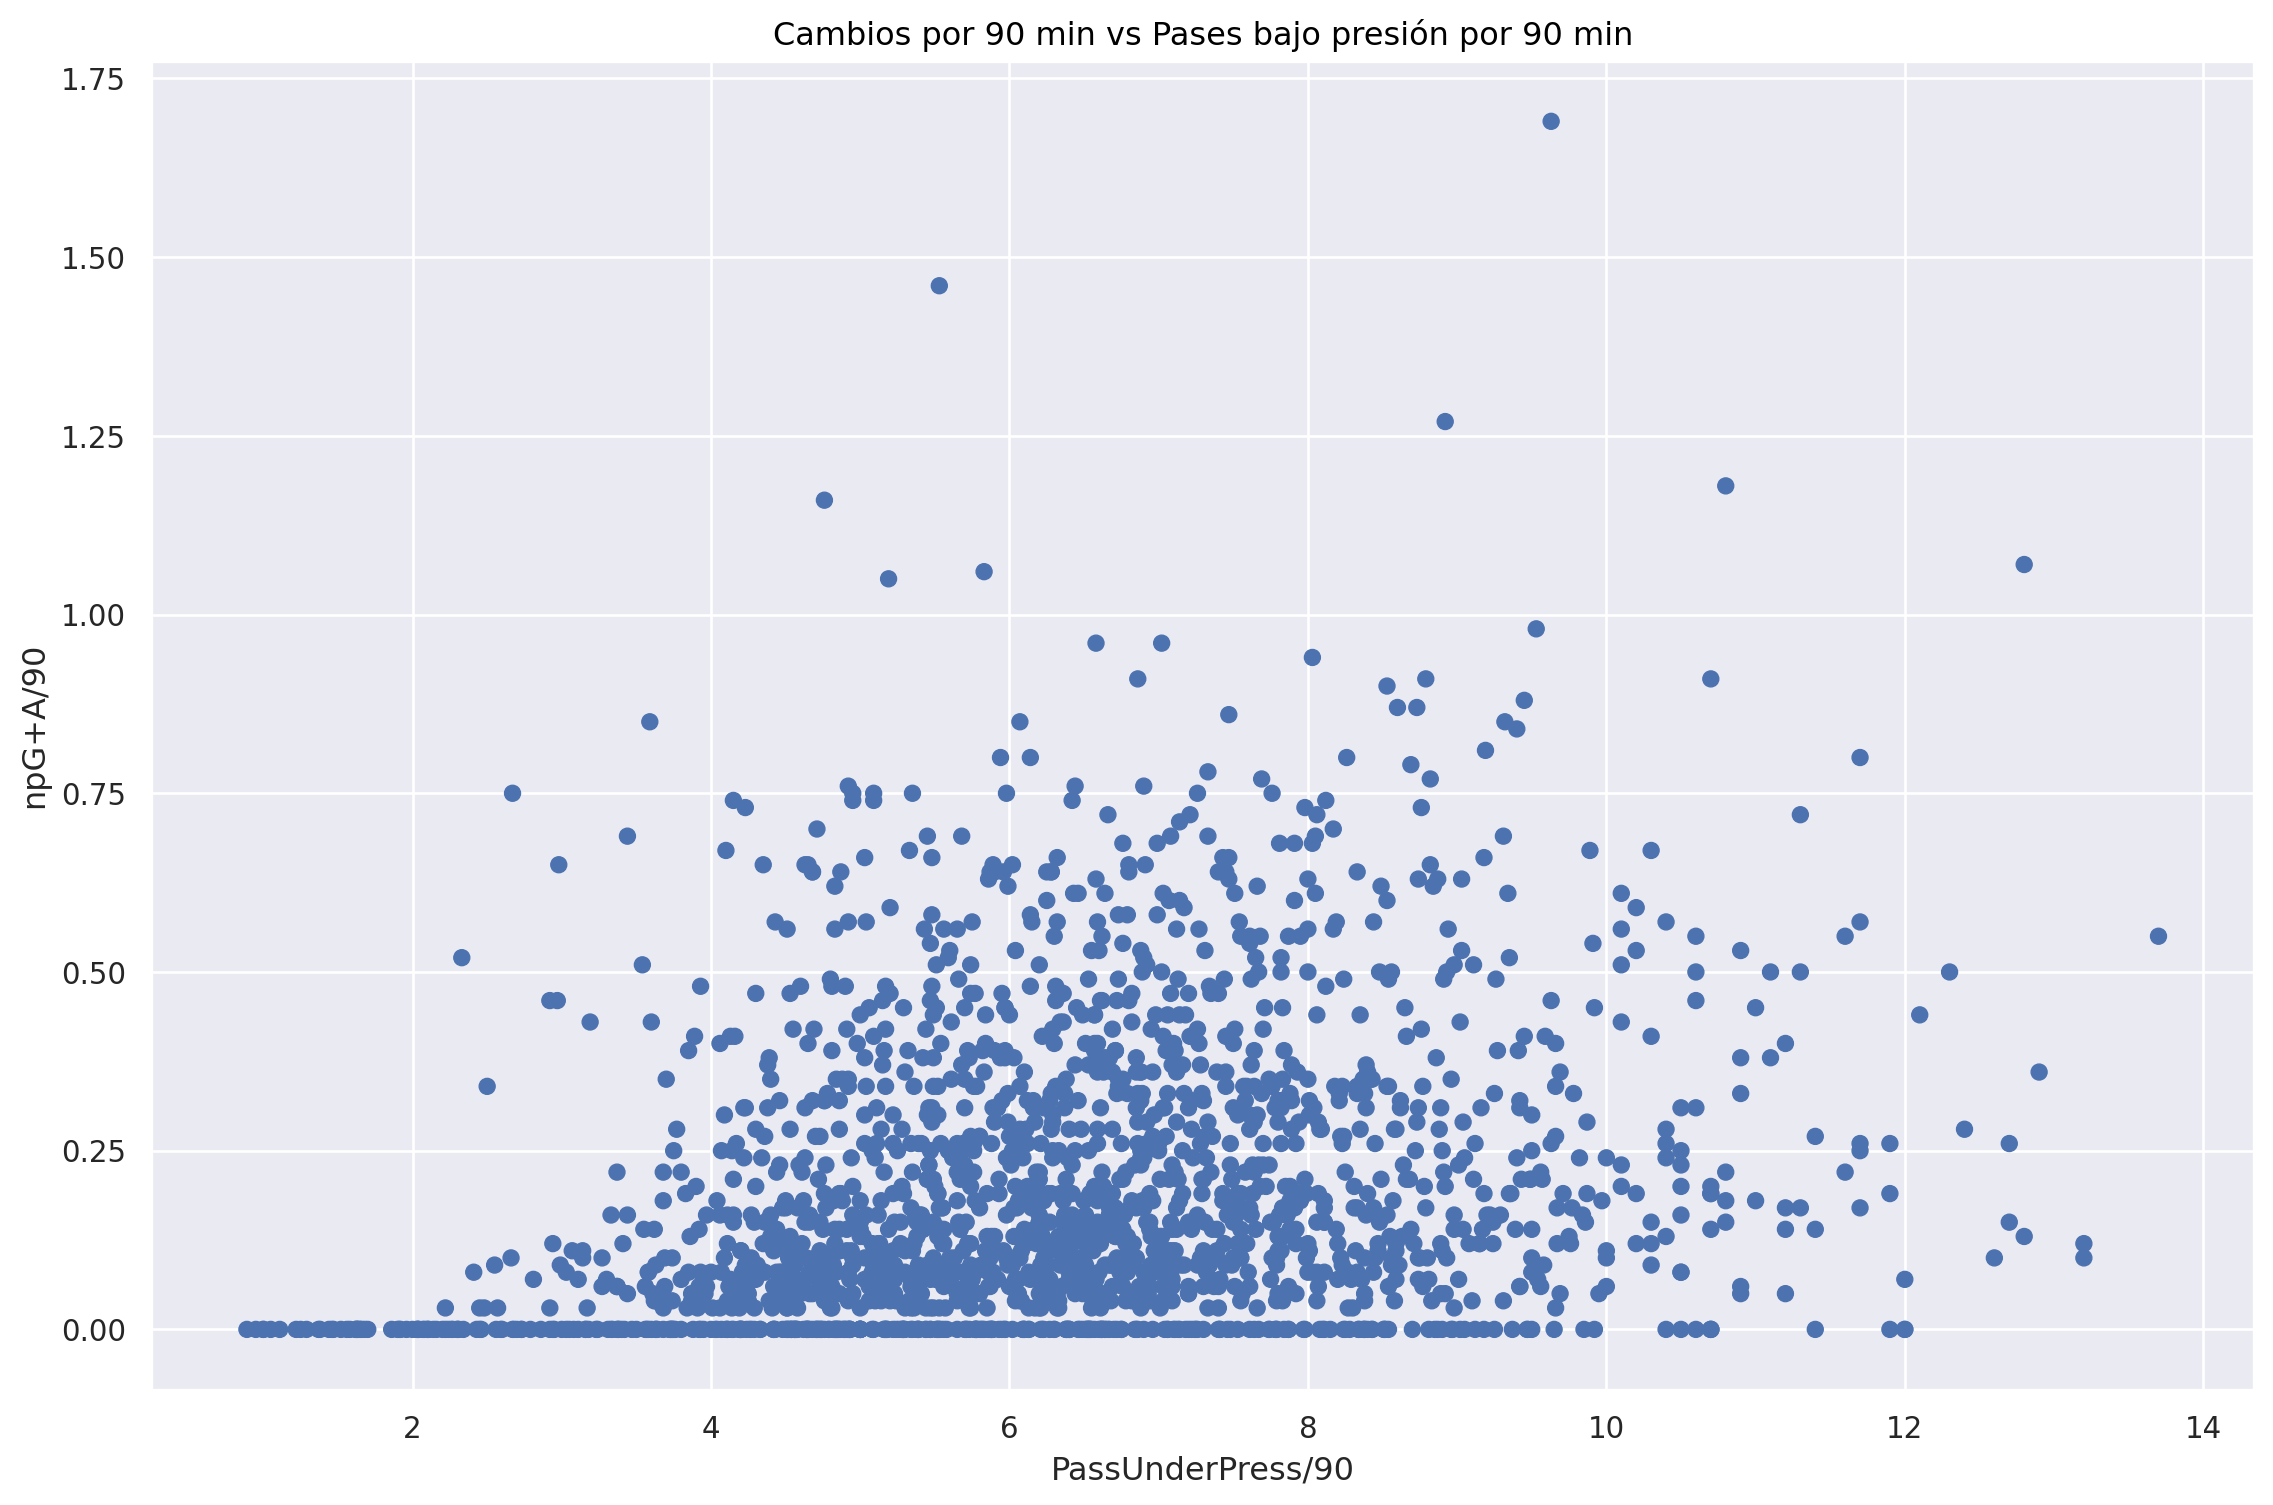

In [15]:
X = "PassUnderPress/90"
# Y = "Switches/90"
Y = "npG+A/90"

(
    so.Plot(data=data_num, x=X, y=Y)
    .add(so.Dot())
    .layout(size=(12, 8))
    .label(title="Cambios por 90 min vs Pases bajo presión por 90 min")
)

In [13]:
# Nos preguntamos si podemos identificar posiciones en este grafico?

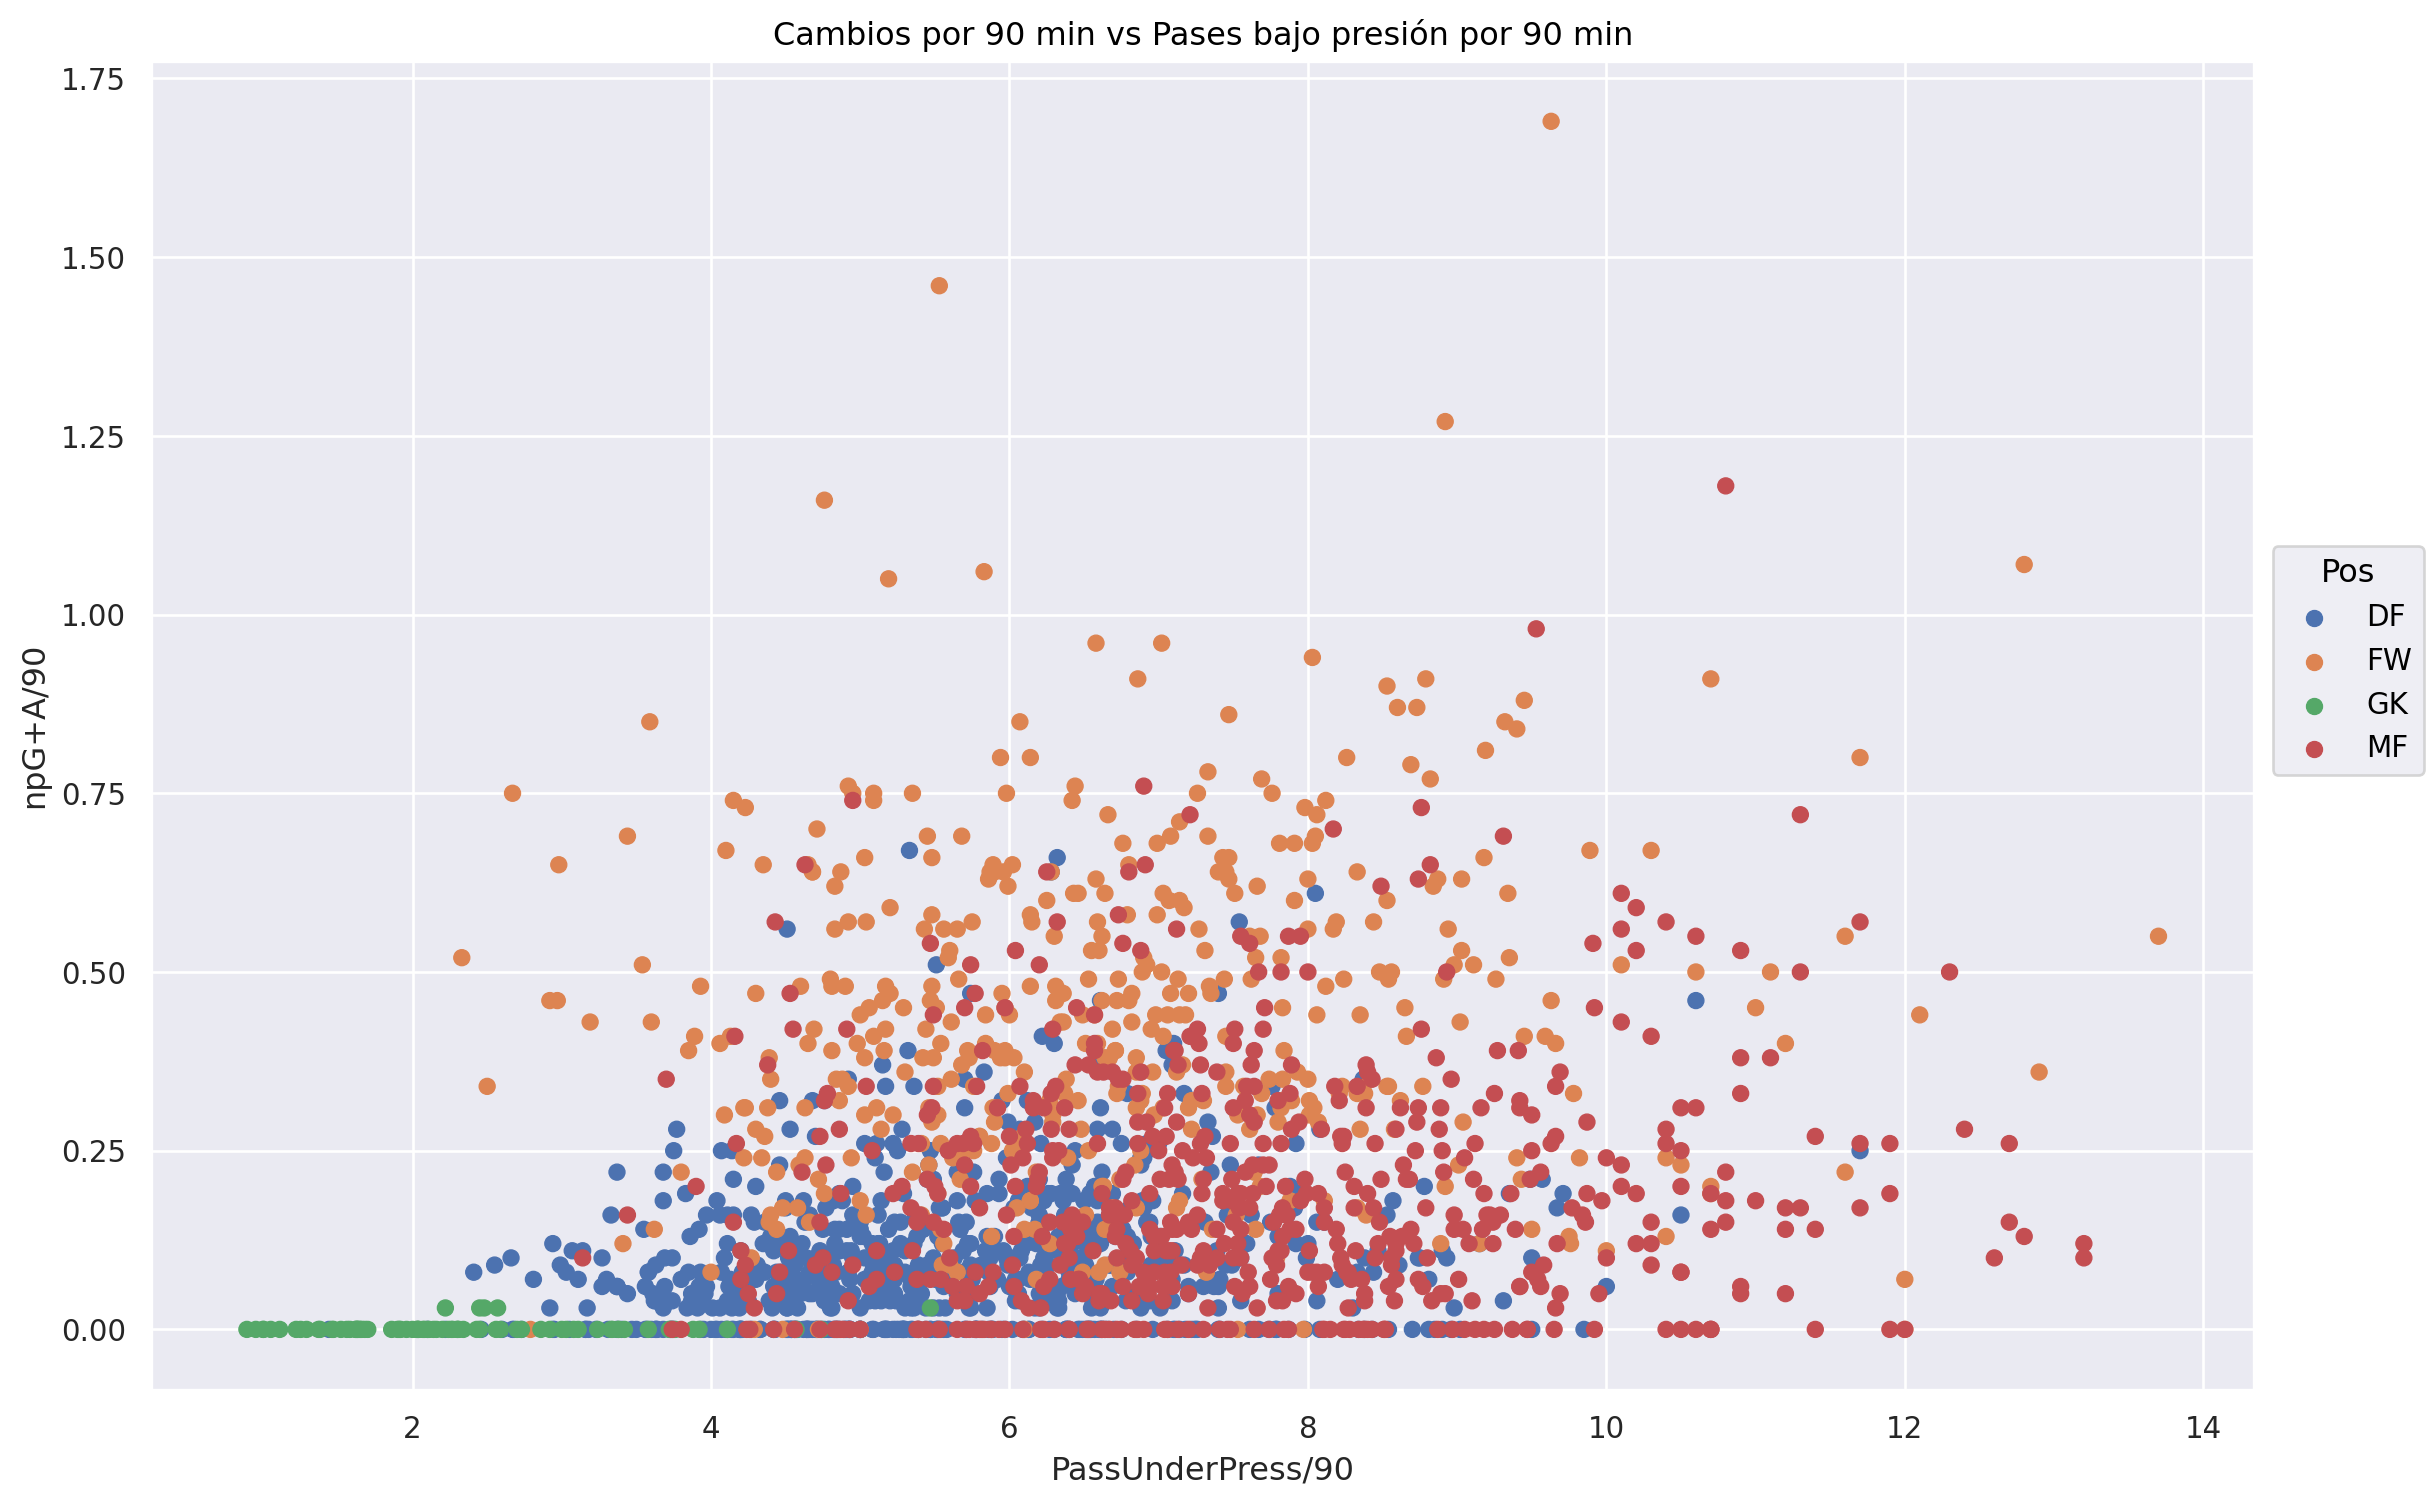

In [16]:
posiciones = (
    data["Pos"].str.split(",").str[0]
)  # Nos quedamos con la primer posición de cada jugador

(
    so.Plot(data=data_num, x=X, y=Y, color=posiciones)
    .add(so.Dot())
    .layout(size=(12, 8))
    .label(title="Cambios por 90 min vs Pases bajo presión por 90 min")
)

Tras elegir dos variables para graficar vemos que no se pueden encontrar fácilmente grupos distintos. ¿Será por el par elegido? 

**Ejercicio:** seleccionar algunas variables más para hacer un cruce y comparar.

### b) Componentes principales
Escalamos los datos (optativo) y realizamos un análisis de componentes principales, quedándonos con las dos primeras componentes.

In [17]:
# Escalamos los datos
data_scaled = StandardScaler().set_output(transform="pandas").fit_transform(data_num)
data_scaled

,Ast/90,npG/90,npG+A/90,xA/90,npxG/90,npxG+xA/90,Shots/90,SoTs/90,FKSht/90,np:G-xG,...,PrgDistCarry/90,ProgCarry/90,CarryIntoThird/90,CarryIntoBox/90,Miscontrol/90,Dispossessed/90,PassTarget/90,PassesReceived/90,PassRec%,ProgPassReceived/90
0,-0.368990,-0.755263,-0.725773,-0.577198,-0.443008,-0.573851,-0.247304,-0.219636,0.978454,-0.735460,...,-0.074387,0.783800,0.374041,0.212073,-0.555069,-0.358168,-0.179105,0.163181,0.611653,-0.322380
1,-0.839441,-0.164862,-0.537698,-0.949976,-0.519206,-0.793152,-0.726631,-0.582580,-0.402602,0.555225,...,0.648976,-0.939363,-1.135684,-0.722041,-0.972806,-0.752355,-0.063129,0.408780,0.896226,-1.015380
2,-0.839441,-0.755263,-0.960866,-1.074236,-0.290611,-0.628676,-0.225516,-0.452957,-0.402602,-1.122665,...,0.378520,-1.229443,-1.349661,-0.787212,-1.084881,-1.216105,-0.844036,-0.328019,0.943654,-1.087295
3,-0.839441,-0.296063,-0.631735,-0.701458,-0.519206,-0.683502,-0.519649,-0.608505,-0.402602,0.297088,...,-0.162393,-0.320237,-0.648293,-0.787212,-1.003372,-1.297261,-0.758986,-0.289644,0.828470,-0.894432
4,-0.557170,-0.755263,-0.819810,-0.701458,-0.671603,-0.793152,-0.955400,-0.997373,-0.402602,-0.348254,...,1.417415,-0.116748,-0.220339,-0.722041,-0.769032,-0.995824,0.485825,0.946029,0.916552,-0.858475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1897,-0.839441,0.163138,-0.302605,-1.074236,-0.214413,-0.628676,-0.029428,-0.634429,-0.402602,0.813362,...,-0.514415,-0.220657,0.219502,0.125179,-0.239220,-0.172669,-1.045061,-1.241342,-1.109331,-0.178550
1898,0.948273,0.491138,0.872860,0.292617,0.776165,0.687134,1.081739,1.180290,-0.402602,-0.348254,...,0.818548,2.048030,0.944645,1.450318,1.003800,1.693922,1.042511,0.546930,-0.513084,1.612789
1899,0.760092,0.163138,0.496711,1.162432,-0.062016,0.413007,-0.116578,0.065534,-0.126391,0.426157,...,0.891528,1.502506,1.562800,1.602383,1.126065,2.018547,0.354385,-0.128469,-0.790881,1.596444
1900,1.136453,0.622338,1.013916,0.665395,0.014182,0.303356,0.362748,0.635874,0.241891,1.200568,...,0.037230,0.545674,0.231389,1.645830,1.767952,1.543204,-0.333740,-0.704093,-0.980596,0.923058


In [18]:
# Componentes principales
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(data_scaled)
print(principalComponents)

[[-2.72172986  2.4562197 ]
 [-7.15401635 -0.92281615]
 [-6.98063265 -3.3786926 ]
 ...
 [ 7.09056586  0.91846771]
 [ 6.92208554 -1.47514622]
 [ 2.60596569  2.10257455]]


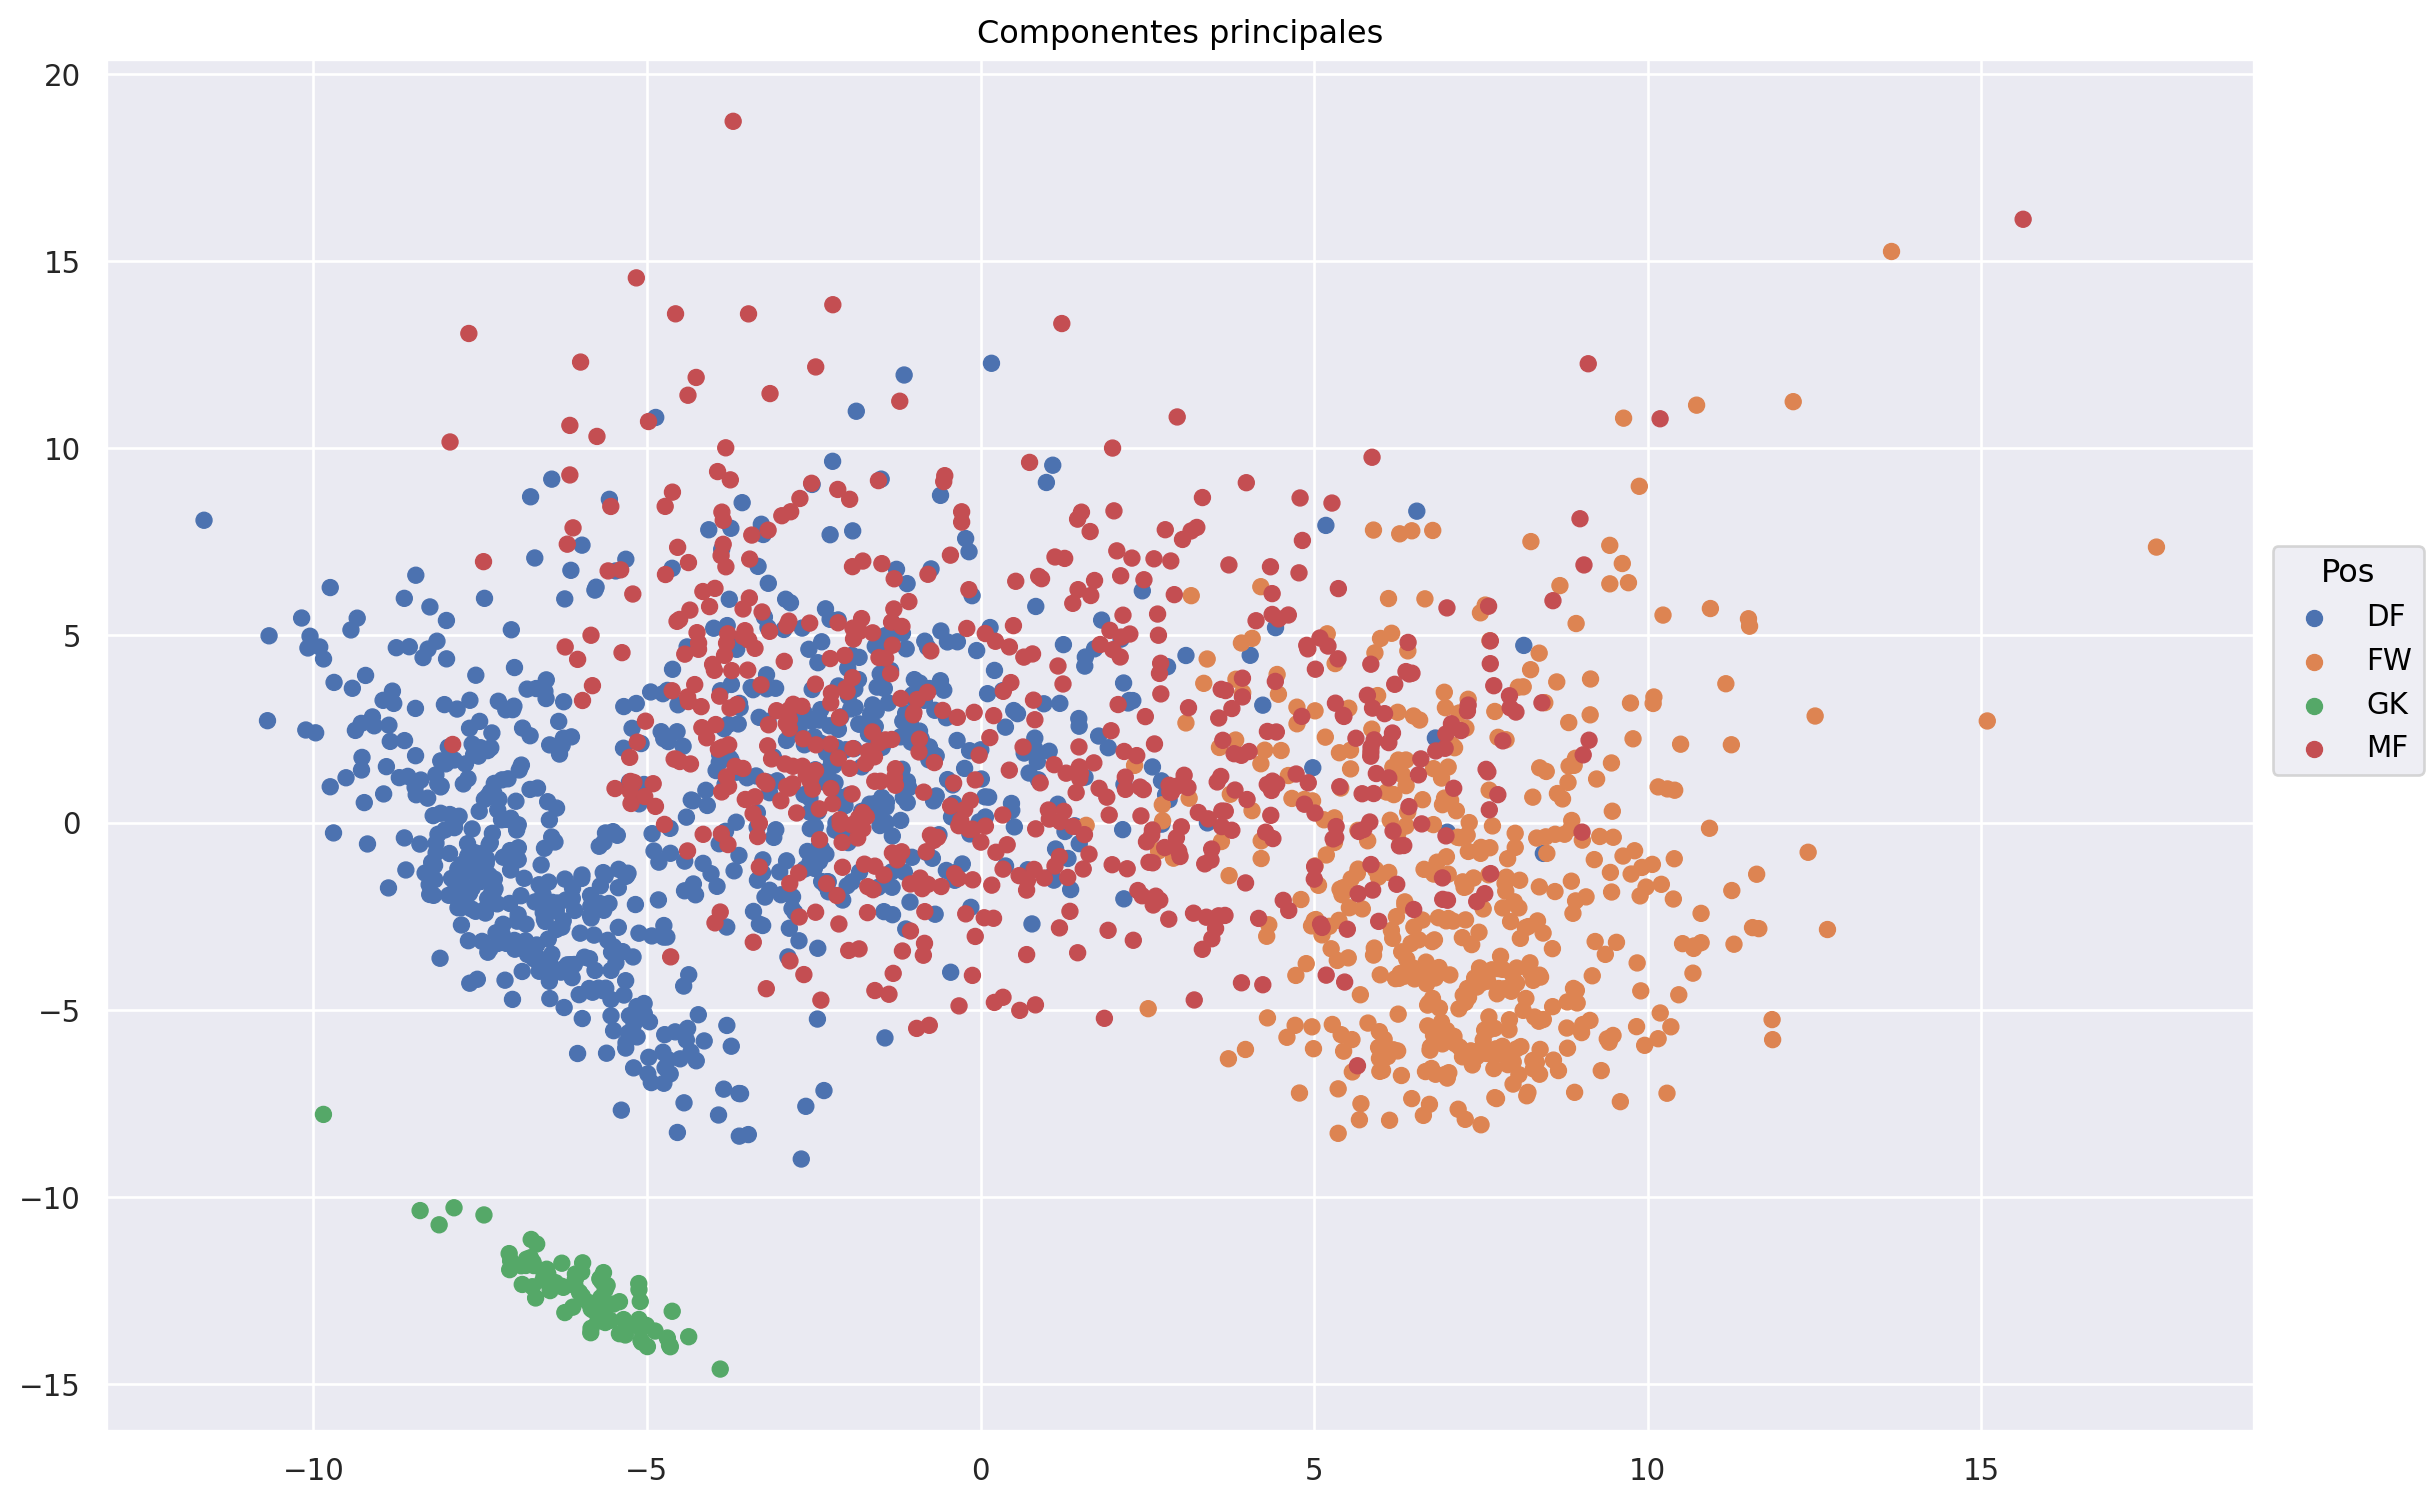

In [20]:
# Graficamos
(
    so.Plot(x=principalComponents[:, 0], y=principalComponents[:, 1], color = posiciones)
    .add(so.Dot())
    .layout(size=(12, 8))
    .label(title="Componentes principales")
)

**Ejercicio:** agregar colores por posición

In [21]:
pca.components_

array([[ 0.0978309 ,  0.12235278,  0.13646434,  0.11786872,  0.13998799,
         0.15257913,  0.14846314,  0.14481143,  0.04804912,  0.00388841,
        -0.11217634, -0.10807911, -0.09704054, -0.1387503 , -0.14075163,
        -0.0220899 , -0.0066418 , -0.11890092, -0.13395788, -0.12904192,
        -0.1286844 , -0.13709736, -0.12861211, -0.05639394,  0.11292689,
        -0.06678811,  0.08581937,  0.04163036, -0.02132407, -0.1028429 ,
        -0.04243525, -0.10213642,  0.05971853,  0.04562776, -0.05339398,
         0.06916766, -0.09606843, -0.00891837, -0.08881047, -0.02561192,
        -0.06728966, -0.06357359, -0.02772924, -0.01949978,  0.00689255,
        -0.05675786,  0.03777891,  0.07871694,  0.12795614,  0.11575816,
         0.04020264,  0.11591618,  0.10584863,  0.1143932 ,  0.05119275,
         0.11975998,  0.10027436,  0.02938621,  0.07500306,  0.0624046 ,
         0.07322235,  0.03548802, -0.04215959, -0.03407107, -0.08399991,
        -0.0121418 ,  0.07797901, -0.05615928, -0.0

# Componentes principales paso a paso

**Ejercicio 1.** Utilizando los datos de pingüinos, 
1. Construir la matrix de datos $X$ con las variables "bill_length_mm" y "bill_depth_mm".
2. Construir la matriz $X^\star$ de datos normalizados (media 0).
3. Construir la matriz de covarianza $\Sigma$.
4. Comparar con el resultado de `np.cov(X.transpose(), bias = 1))`

In [22]:
# Eliminamos datos faltantes y reseteamos los índices, para no tener problemas al graficar
penguins = sns.load_dataset("penguins").dropna().reset_index(drop=True)

# Normalizamos las variables "bill_length_mm" y "bill_depth_mm" por MinMax
penguins[["bill_length_mm", "bill_depth_mm"]] = StandardScaler().fit_transform(penguins[["bill_length_mm", "bill_depth_mm"]])

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,-0.896042,0.780732,181.0,3750.0,Male
1,Adelie,Torgersen,-0.822788,0.119584,186.0,3800.0,Female
2,Adelie,Torgersen,-0.676280,0.424729,195.0,3250.0,Female
3,Adelie,Torgersen,-1.335566,1.085877,193.0,3450.0,Female
4,Adelie,Torgersen,-0.859415,1.747026,190.0,3650.0,Male


In [23]:
# Item 1
# Nos quedamos con las variables de longitud y profundidad del pico
X = penguins[["bill_length_mm", "bill_depth_mm"]]
X.head()

,bill_length_mm,bill_depth_mm
0,-0.896042,0.780732
1,-0.822788,0.119584
2,-0.676280,0.424729
3,-1.335566,1.085877
4,-0.859415,1.747026


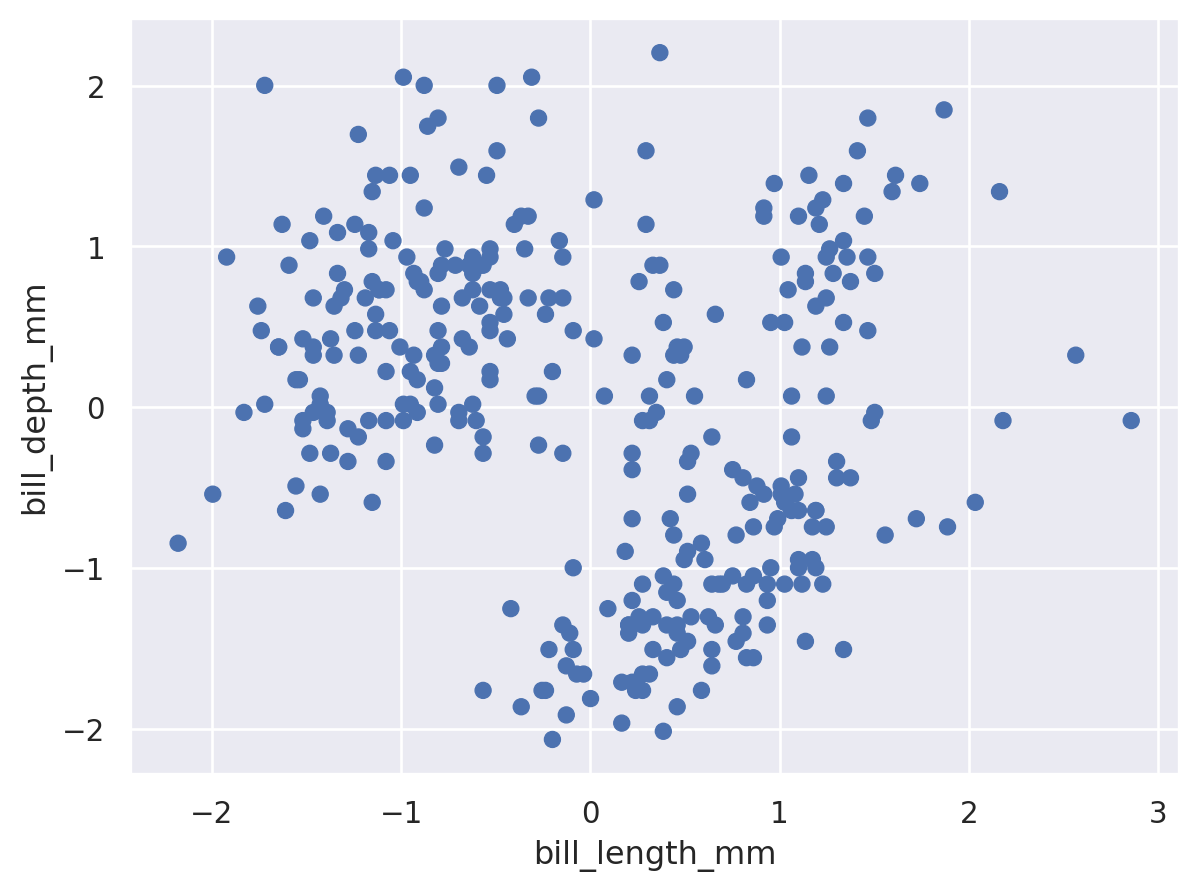

In [24]:
# Graficamos
(
    so.Plot(data = X, x = "bill_length_mm", y = "bill_depth_mm")
    .add(so.Dot())
)

In [25]:
# Media de cada columna 
X.mean()

bill_length_mm    3.840772e-16
bill_depth_mm     6.401286e-16
dtype: float64

In [26]:
X_star = X - X.mean()
X_star.head()

,bill_length_mm,bill_depth_mm
0,-0.896042,0.780732
1,-0.822788,0.119584
2,-0.676280,0.424729
3,-1.335566,1.085877
4,-0.859415,1.747026


In [27]:
# Verificamos que cada columna tiene media 0
X_star.mean()

bill_length_mm    0.000000e+00
bill_depth_mm    -4.267524e-17
dtype: float64

In [30]:
# Calculamos la matriz de covarianza
n = len(X_star)
Sigma = X_star.T @ X_star / n
Sigma
# En la diagonal queda la varianza. Da 1 porque usamos StandardScaler() antes

,bill_length_mm,bill_depth_mm
bill_length_mm,1.000000,-0.228626
bill_depth_mm,-0.228626,1.000000


In [31]:
# Comparamos con el comando np.cov de Numpy
# Tenemos que pasarle las variables como columnas.
# Si no usamos bias = 1, divide por n-1 en lugar de n.
np.cov(X.transpose(), bias = 1)

array([[ 1.        , -0.22862564],
       [-0.22862564,  1.        ]])

**Ejercicio 2**
1. Calcular las componentes principales de la matriz X del ejercicio anterior.
2. Graficar los datos normalizados y las componentes principales.
3. Realizar un nuevo gráfico con los datos transformados.

In [32]:
# eigh es un comando especial para calcular autovalores y autovectores de matrices simétricas
# Devuelve una dupla:
# - la primer componente es el vector de autovalores, ordenados de menor a mayor
# - la segunda componente es la matriz de autovectores. la i-ésima columna de U es el autovector correspondiente al i-ésimo autovalor
gamma, U = np.linalg.eigh(Sigma) 
print(gamma)
print(U)

[0.77137436 1.22862564]
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


In [33]:
# Los autovalores que nos devuelve eigh están siempre ordenados de menor a mayor.
# Damos vueltas los autovalores y las columnas de la matriz de autovectores usando np.flip(-,1)
gamma = np.flip(gamma)
print(gamma)

U = np.flip(U, 1)   # U tiene los autovectores de Sigma como columnas
print(U)

[1.22862564 0.77137436]
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]


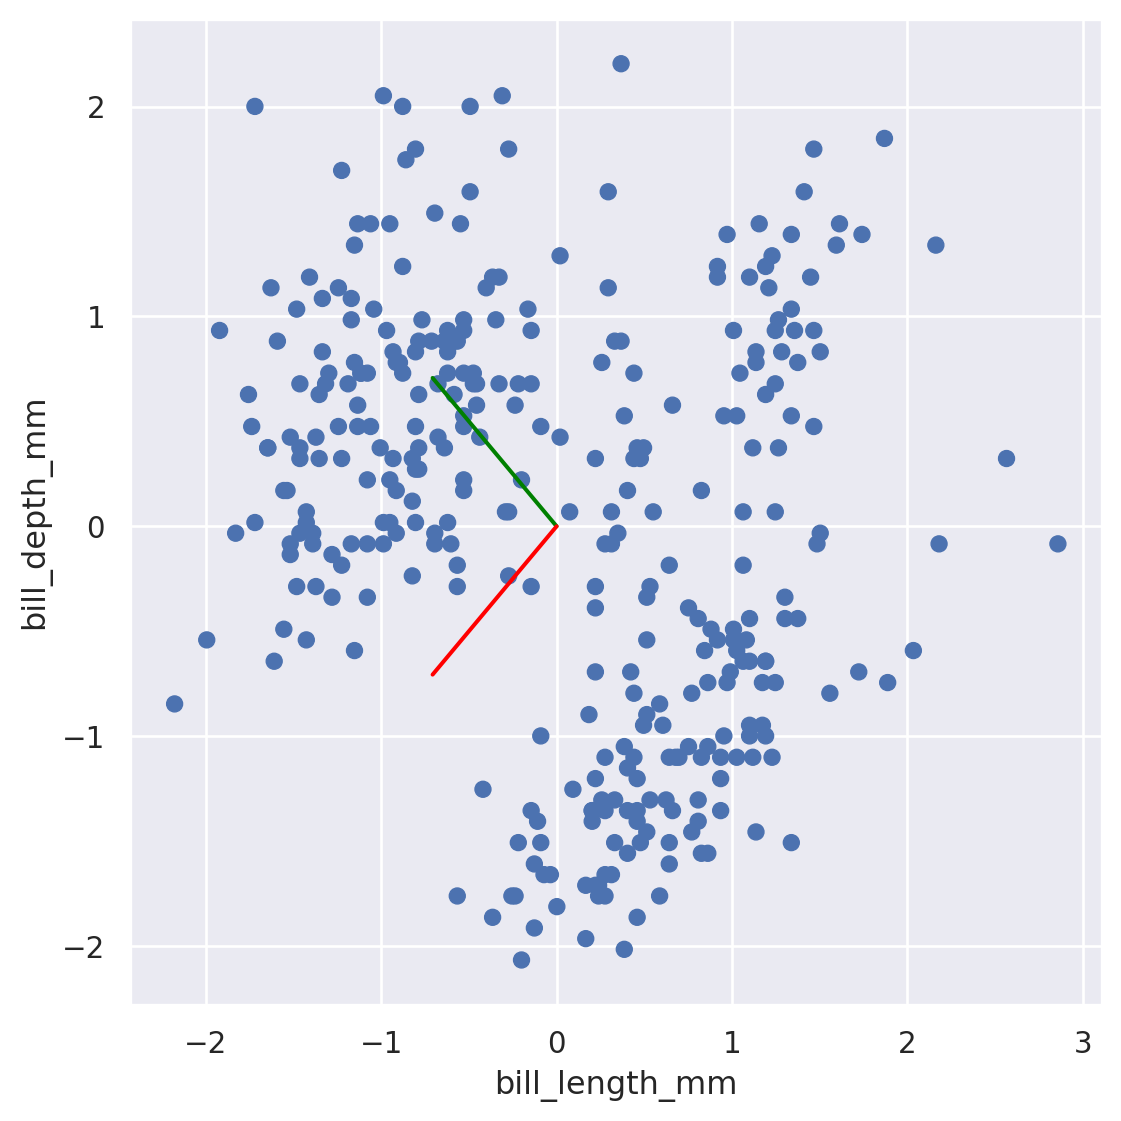

In [34]:
# Graficamos los autovectores
(
    so.Plot()
    .add(so.Dot(), x = X_star["bill_length_mm"], y = X_star["bill_depth_mm"])
    .add(so.Line(color = "green"), x = [0, U[0,0]], y = [0, U[1,0]]) # Primera dirección principal
    .add(so.Line(color = "red"), x = [0, U[0,1]], y = [0, U[1,1]]) # Segunda dirección principal
    .layout(size = (6,6))
)

In [35]:
# Calculamos las nuevas variables Z correspondientes a las componentes principales
Z = X_star @ U
Z.columns = ["Z1", "Z2"]  # Renombramos las columnas
Z

,Z1,Z2
0,1.185658,0.081536
1,0.666358,0.497240
2,0.778531,0.177873
3,1.712219,0.176557
4,1.843032,-0.627636
...,...,...
328,-1.661346,0.830704
329,-1.393777,0.666732
330,-1.356499,-0.302917
331,-1.006775,0.694117


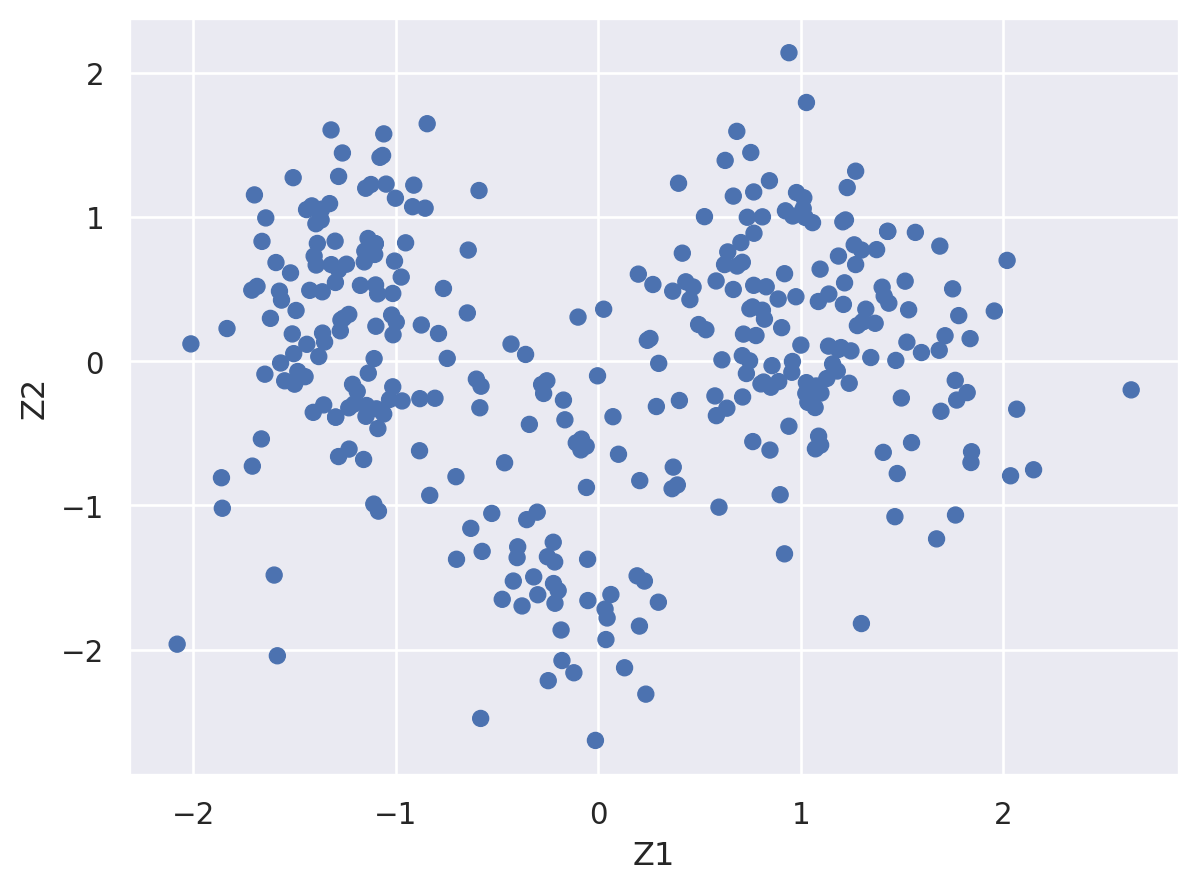

In [36]:
# Graficamos las nuevas variables.
(
    so.Plot(data = Z, x = "Z1", y = "Z2")
    .add(so.Dot())
)

**Ejercicio:** Para la matriz de covarianza
$$
M = \left(
   \begin{array}{cccc}
    3 & 1/2 & 1/3 & 0\\
    1/2 & 4 & 1/6 & 3/4\\
    1/3 & 1/6 & 2 & 0 \\
    0 & 3/4 & 0 & 5
   \end{array}
   \right)
$$
calcular la varianza explicada acumulada de las dos primeras componentes principales.

In [41]:
M = np.array([
    [3, 1/2, 1/3, 0],
    [1/2, 4, 1/6, 3/4],
    [1/3, 1/6, 2, 0],
    [0, 3/4, 0, 5]
])

gamma, U = np.linalg.eigh(M)
gamma

array([1.89894816, 2.80523754, 3.86645522, 5.42935908])

In [42]:
(gamma[2]+gamma[3])/gamma.sum()

np.float64(0.6639867360267888)

### Aplicación

En el archivo `paises.csv` se encuentran 11 variables ecónomicas y sociales asociadas a 21 países. Queremos usar esas variables para visualizar países con comportamientos similares.

In [43]:
# Leemos los datos
datos = pd.read_csv("paises.csv", index_col = "Pais")   # dataFrame
X = datos
X.columns = X.columns.str.strip()  # Los nombres tienen un espacio al principio, lo eliminamos
display(X)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11
Pais,,,,,,,,,,,
Albania,1.0,30,41,2199,3903,12,94,53,0.0,341,1.2
Angola,3.0,124,46,4422,955,6,57,19,0.7,89,0.5
Arabia Saudi,4.3,21,13,133540,91019,96,497,1,0.0,4566,13.1
Argelia,2.5,34,24,44609,19883,42,180,2,0.8,906,3.0
Argentina,1.3,22,31,278431,65962,160,1043,22,0.1,1504,3.5
Australia,1.4,6,43,337909,167155,510,933,19,0.0,5341,15.3
Austria,0.6,6,41,216547,53259,465,304,47,-0.4,3301,7.2
Bangladesh,2.0,79,42,28599,9891,2,220,6,4.1,64,0.2
Belgica,0.3,8,40,250710,72236,457,917,20,-0.3,5120,10.1


In [44]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11'], dtype='object')

Los variables corresponden a los siguientes indicadores:

1. X1 = Tasa anual de crecimiento de la población
2. X2 = Tasa de mortalidad infantil por cada 1000 nacidos vivos, 
3. X3 = Porcentaje de mujeres en la población activa, 
4. X4 = PNB en 1995 (en millones de dólares), 
5. X5 = Producción de electricidad (en millones kW/h), 
6. X6 = Líneas telefónicas por cada 1000 habitantes, 
7. X7 = Consumo de agua per cápita, 
8. X8 = Proporción de la superficie del país cubierta por bosques, 
9. X9 = Proporción de deforestación anual, 
10. X10 = Consumo de energía per cápita, 
11. X11 = Emisión de CO2 per cápita.

In [45]:
# Para más adelante
col_details = pd.Series({
    "X1": "Tasa anual de crecimiento de la población",
    "X2": "Tasa de mortalidad infantil por cada 1000 nacidos vivos",
    "X3": "Porcentaje de mujeres en la población activa",
    "X4": "PNB en 1995 (en millones de dólares)",
    "X5": "Producción de electricidad (en millones kW/h)",
    "X6": "Líneas telefónicas por cada 1000 habitantes",
    "X7": "Consumo de agua per cápita",
    "X8": "Proporción de la superficie del país cubierta por bosques",
    "X9": "Proporción de deforestación anual",
    "X10": "Consumo de energía per cápita",
    "X11": "Emisión de CO2 per cápita"
})

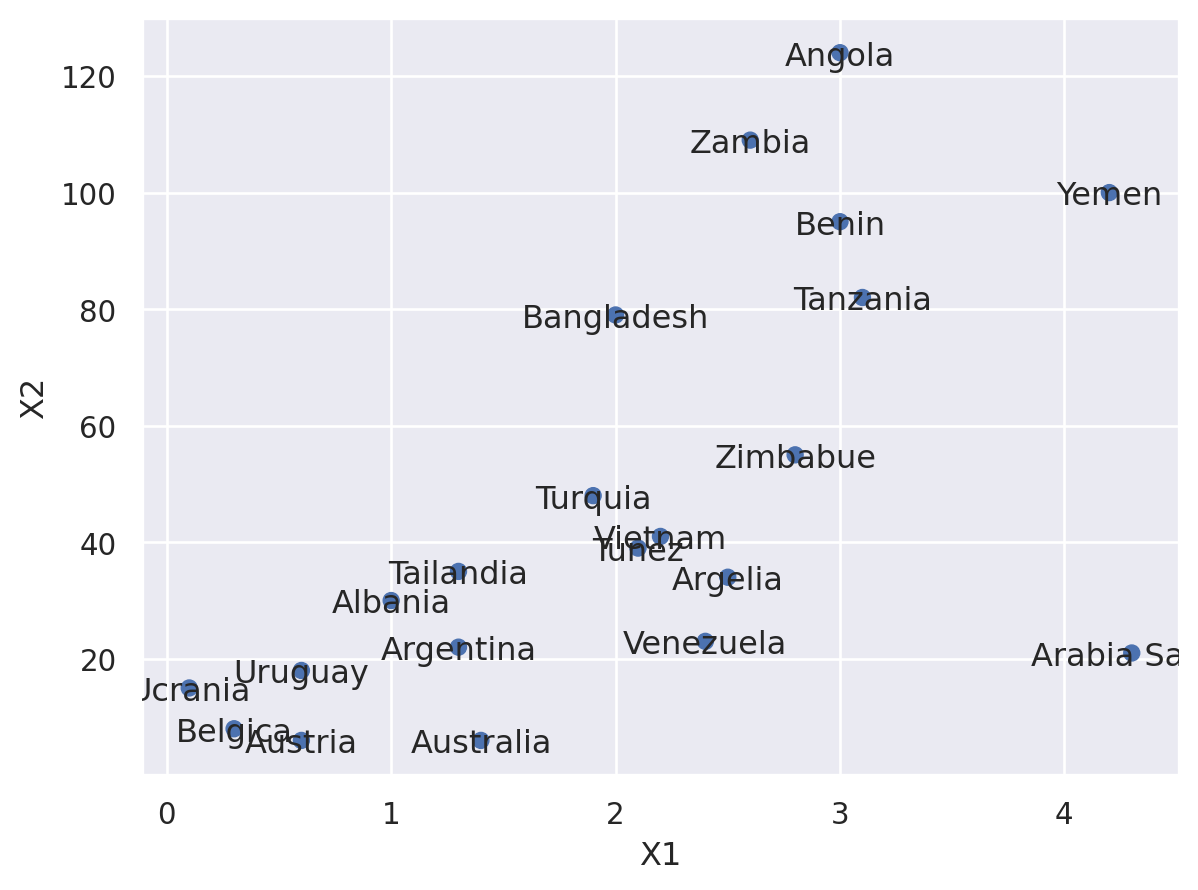

In [46]:
# Graficamos algunos pares de variables
(
    so.Plot(data = X, x = "X1", y = "X2", text = X.index)
    .add(so.Dot())
    .add(so.Text())
)

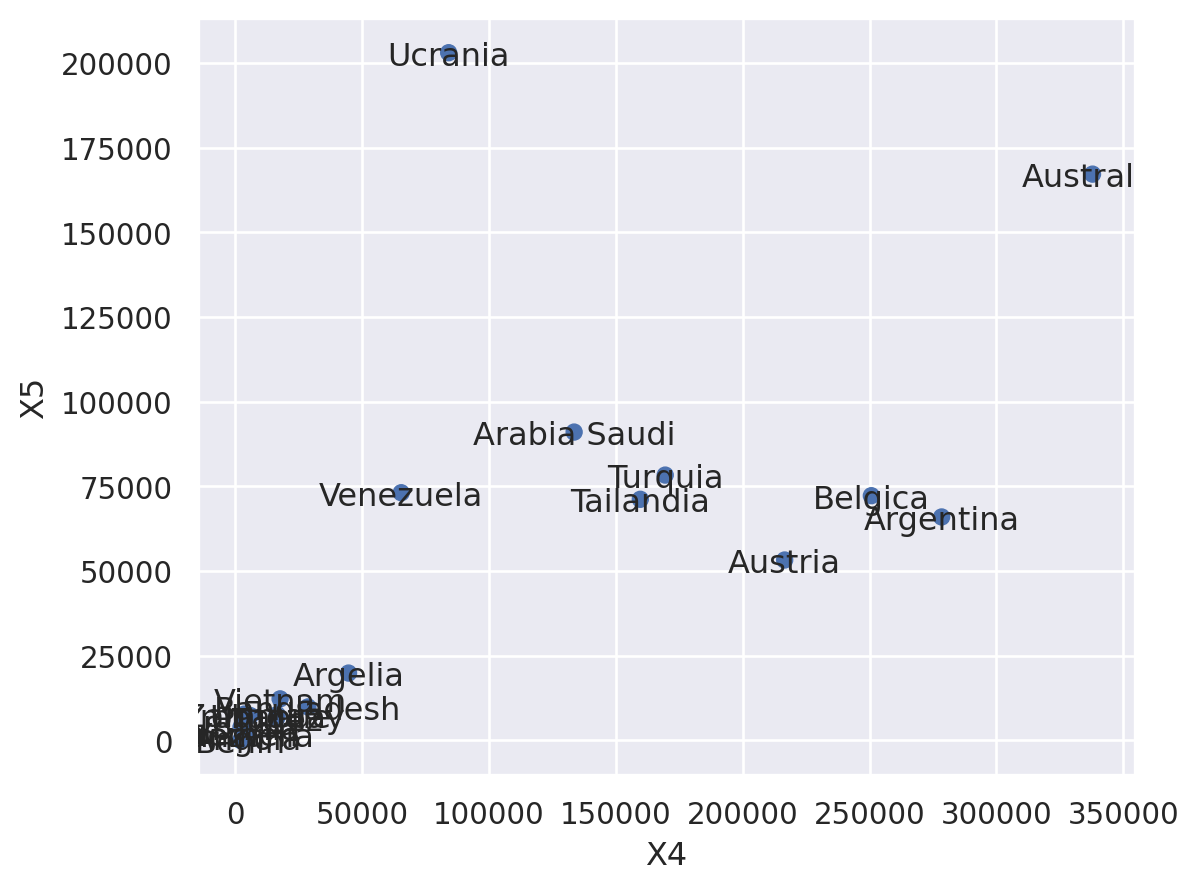

In [47]:
# Graficamos la información de dos variables 

# X4 = PNB en 1995 (en millones de dólares),
# X5 = Producción de electricidad (en millones kW/h),
(
    so.Plot(data = X, x = "X4", y = "X5", text = X.index)
    .add(so.Dot())
    .add(so.Text())
)

In [48]:
# En estos ejemplos los países aparecen muy juntos, queremos ver si encontramos nuevas variables que nos permitan separar mejor a los países.

In [49]:
# Como tenemos datos en distintas escalas llevamos los datos a media 0 y varianza 1.
# Esta normalización se obtiene restando la media y dividiendo por el desvío estandar.
X_star = StandardScaler().set_output(transform="pandas").fit_transform(X)
display(X_star)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11
Pais,,,,,,,,,,,
Albania,-0.902226,-0.482339,0.222849,-0.825028,-0.754949,-0.703428,-1.009178,1.776586,-0.466125,-0.642429,-0.591345
Angola,0.844018,2.162486,0.767014,-0.803620,-0.808442,-0.741241,-1.134199,-0.289346,0.073405,-0.788122,-0.743052
Arabia Saudi,1.979077,-0.735567,-2.824479,0.439794,0.825820,-0.174057,0.352536,-1.383075,-0.466125,1.800234,1.987664
Argelia,0.407457,-0.369793,-1.627314,-0.416617,-0.464983,-0.514367,-0.718589,-1.322312,0.150481,-0.315777,-0.201243
Argentina,-0.640290,-0.707430,-0.865482,1.835103,0.371147,0.229274,2.197440,-0.107058,-0.389049,0.029953,-0.092881
Australia,-0.552978,-1.157613,0.440515,2.407879,2.207351,2.434991,1.825756,-0.289346,-0.466125,2.248296,2.464455
Austria,-1.251475,-1.157613,0.222849,1.239156,0.140644,2.151399,-0.299600,1.412010,-0.774428,1.068880,0.708995
Bangladesh,-0.029104,0.896346,0.331682,-0.570794,-0.646293,-0.766449,-0.583431,-1.079261,2.693982,-0.802576,-0.808069
Belgica,-1.513412,-1.101340,0.114016,1.568148,0.484992,2.100982,1.771693,-0.228584,-0.697352,2.120526,1.337493


In [50]:
# Calculamos la matriz de covarianza:
# cov = (X - Xraya)^T * (X - Xraya) / N = (B^T * B) / N
X_star_t = np.transpose(X_star)
N = len(X_star)
Sigma = (X_star_t @ X_star) / N
display(Sigma)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11
X1,1.000000,0.629606,-0.380853,-0.446483,-0.425196,-0.583977,-0.442263,-0.139033,0.162366,-0.325678,-0.278883
X2,0.629606,1.000000,0.258119,-0.626758,-0.597896,-0.656055,-0.615723,0.083098,0.350169,-0.684482,-0.663817
X3,-0.380853,0.258119,1.000000,-0.155930,-0.030875,-0.014938,-0.187816,0.460945,0.333558,-0.270369,-0.263690
X4,-0.446483,-0.626758,-0.155930,1.000000,0.672974,0.835755,0.860429,-0.034205,-0.170113,0.773268,0.700910
X5,-0.425196,-0.597896,-0.030875,0.672974,1.000000,0.588598,0.727782,-0.098846,-0.175931,0.767040,0.857659
X6,-0.583977,-0.656055,-0.014938,0.835755,0.588598,1.000000,0.638939,0.020698,-0.398086,0.817128,0.721509
X7,-0.442263,-0.615723,-0.187816,0.860429,0.727782,0.638939,1.000000,-0.232275,-0.210303,0.682377,0.648466
X8,-0.139033,0.083098,0.460945,-0.034205,-0.098846,0.020698,-0.232275,1.000000,0.126503,-0.116264,-0.170226
X9,0.162366,0.350169,0.333558,-0.170113,-0.175931,-0.398086,-0.210303,0.126503,1.000000,-0.351347,-0.344128
X10,-0.325678,-0.684482,-0.270369,0.773268,0.767040,0.817128,0.682377,-0.116264,-0.351347,1.000000,0.967906


In [51]:
# Comparamos con el comando cov de numpy
display(np.cov(np.transpose(X_star), bias = 1))

# Tenemos que transponer X porque cov requiere variables en filas
# El parámetro bias = 1 hace que divida por N. Si no lo ponemos, o ponemos bias = 0, divide por N-1.

array([[ 1.        ,  0.62960563, -0.38085272, -0.44648335, -0.42519569,
        -0.58397672, -0.44226306, -0.13903328,  0.16236635, -0.3256778 ,
        -0.27888323],
       [ 0.62960563,  1.        ,  0.25811855, -0.6267577 , -0.59789643,
        -0.65605528, -0.6157233 ,  0.0830981 ,  0.35016856, -0.68448239,
        -0.66381678],
       [-0.38085272,  0.25811855,  1.        , -0.15593001, -0.03087508,
        -0.01493831, -0.18781641,  0.46094529,  0.33355766, -0.27036942,
        -0.26368959],
       [-0.44648335, -0.6267577 , -0.15593001,  1.        ,  0.6729744 ,
         0.83575465,  0.86042885, -0.03420469, -0.17011318,  0.77326805,
         0.70090974],
       [-0.42519569, -0.59789643, -0.03087508,  0.6729744 ,  1.        ,
         0.58859806,  0.72778184, -0.09884628, -0.17593148,  0.76703996,
         0.85765874],
       [-0.58397672, -0.65605528, -0.01493831,  0.83575465,  0.58859806,
         1.        ,  0.63893862,  0.02069816, -0.39808578,  0.81712791,
         0.721

Obtuvimos la misma matriz!

Ahora podemos calcular las componentes principales.
Calculamos primero los autovalores y autovectores de la matriz de covarianza y los ordenamos los autovectores por autovalor.

In [52]:
gamma, U = np.linalg.eigh(Sigma)  # Usamos eigh porque A es simétrica. Podemos usar eig también
display(gamma)
display(U)

array([2.88774979e-03, 3.25582148e-02, 7.81459028e-02, 1.06712764e-01,
       3.55335107e-01, 4.81437963e-01, 5.55648302e-01, 7.88538421e-01,
       9.87267285e-01, 1.80967483e+00, 5.80179346e+00])

array([[-5.00990711e-02,  1.58410366e-01, -3.75722359e-01,
         4.59557273e-01, -4.17835886e-02, -1.61304573e-01,
        -1.10114143e-02,  5.25712075e-01,  2.41768349e-01,
         4.52161932e-01, -2.29944001e-01],
       [ 5.10064788e-02, -3.51761007e-02,  3.34109620e-01,
        -4.89773662e-01, -5.58942175e-02, -6.14321278e-01,
         2.27542828e-01,  2.30561638e-01,  2.08611582e-01,
         2.24073149e-02, -3.39386829e-01],
       [-4.79569764e-02, -1.19634971e-01, -1.31315145e-01,
         4.88161730e-01,  5.18702043e-02, -2.67124067e-01,
         4.59869710e-01, -7.56881984e-02,  8.35168266e-02,
        -6.49484044e-01, -8.82203928e-02],
       [-9.17897113e-02, -6.32703336e-01, -3.24743511e-01,
        -9.53786067e-02, -4.51353153e-04, -3.49845512e-01,
        -4.21670826e-01,  4.79786170e-02,  1.90078782e-01,
        -6.81883990e-02,  3.65274952e-01],
       [-2.46236551e-01,  1.88884109e-01, -3.81797594e-01,
        -3.81892563e-01, -4.22832116e-01,  1.98174051e-01,
  

In [53]:
# Los autovalores están ordenados de menor a mayor.
# Damos vueltas las columnas de la matriz de autovectores usando np.flip(-,1)
gamma = np.flip(gamma)
U = np.flip(U, 1)   # U tiene los autovectores de Sigma como columnas
print(U)

[[-2.29944001e-01  4.52161932e-01  2.41768349e-01  5.25712075e-01
  -1.10114143e-02 -1.61304573e-01 -4.17835886e-02  4.59557273e-01
  -3.75722359e-01  1.58410366e-01 -5.00990711e-02]
 [-3.39386829e-01  2.24073149e-02  2.08611582e-01  2.30561638e-01
   2.27542828e-01 -6.14321278e-01 -5.58942175e-02 -4.89773662e-01
   3.34109620e-01 -3.51761007e-02  5.10064788e-02]
 [-8.82203928e-02 -6.49484044e-01  8.35168266e-02 -7.56881984e-02
   4.59869710e-01 -2.67124067e-01  5.18702043e-02  4.88161730e-01
  -1.31315145e-01 -1.19634971e-01 -4.79569764e-02]
 [ 3.65274952e-01 -6.81883990e-02  1.90078782e-01  4.79786170e-02
  -4.21670826e-01 -3.49845512e-01 -4.51353153e-04 -9.53786067e-02
  -3.24743511e-01 -6.32703336e-01 -9.17897113e-02]
 [ 3.46900282e-01 -5.89703905e-02  2.75037632e-01  9.27843128e-02
   4.31215872e-01  1.98174051e-01 -4.22832116e-01 -3.81892563e-01
  -3.81797594e-01  1.88884109e-01 -2.46236551e-01]
 [ 3.61998663e-01 -1.42056552e-01 -1.67044217e-01  7.49780074e-02
  -1.01065820e-01 -

In [57]:
print(np.round(100*gamma.cumsum()/gamma.sum()))

[ 53.  69.  78.  85.  90.  95.  98.  99. 100. 100. 100.]


In [58]:
# U son las direcciones del nuevo espacio
# Calculamos las componentes principales usando la formula
# Z = (X - Xraya) * U

Z = X_star @ U 
Z.columns = ["Z" + str(i) for i in range(1,12)]  # Renombramos las columnas
display(Z)

,Z1,Z2,Z3,Z4,Z5,Z6,Z7,Z8,Z9,Z10,Z11
Pais,,,,,,,,,,,
Albania,-1.314498,-1.309112,-1.656815,0.276028,-0.440657,1.126621,-0.343799,-0.110856,0.267103,-0.250501,0.072006
Angola,-2.808541,0.101074,0.185414,0.319219,0.891104,-1.148604,0.228074,-0.308467,0.121829,-0.252857,-0.030310
Arabia Saudi,2.142693,3.865327,0.762620,1.324160,0.106606,0.879214,0.240773,0.159893,0.127616,-0.189180,-0.020169
Argelia,-0.717596,1.947052,-0.042520,-0.716696,-0.339690,0.792807,0.542909,-0.355942,-0.195000,-0.089935,-0.010125
Argentina,2.161233,0.260380,0.292491,-0.839664,-1.587065,-0.667285,-1.282206,0.006468,0.071271,-0.272499,0.041298
Australia,5.521872,-0.442334,0.854318,0.732831,0.548201,-0.792468,0.352200,0.193013,-0.376689,-0.038980,0.123493
Austria,2.555125,-1.517681,-1.476238,0.840427,-0.669239,-0.031991,1.054482,-0.308736,-0.305054,-0.030553,-0.020338
Bangladesh,-2.232710,-0.278718,2.144314,-1.165945,-0.155295,0.304232,0.994898,-0.356474,0.207898,0.072934,0.052687
Belgica,4.273571,-0.572201,-0.309189,-0.263386,-0.280263,-0.752785,0.681625,0.267013,0.794839,0.104901,-0.089732


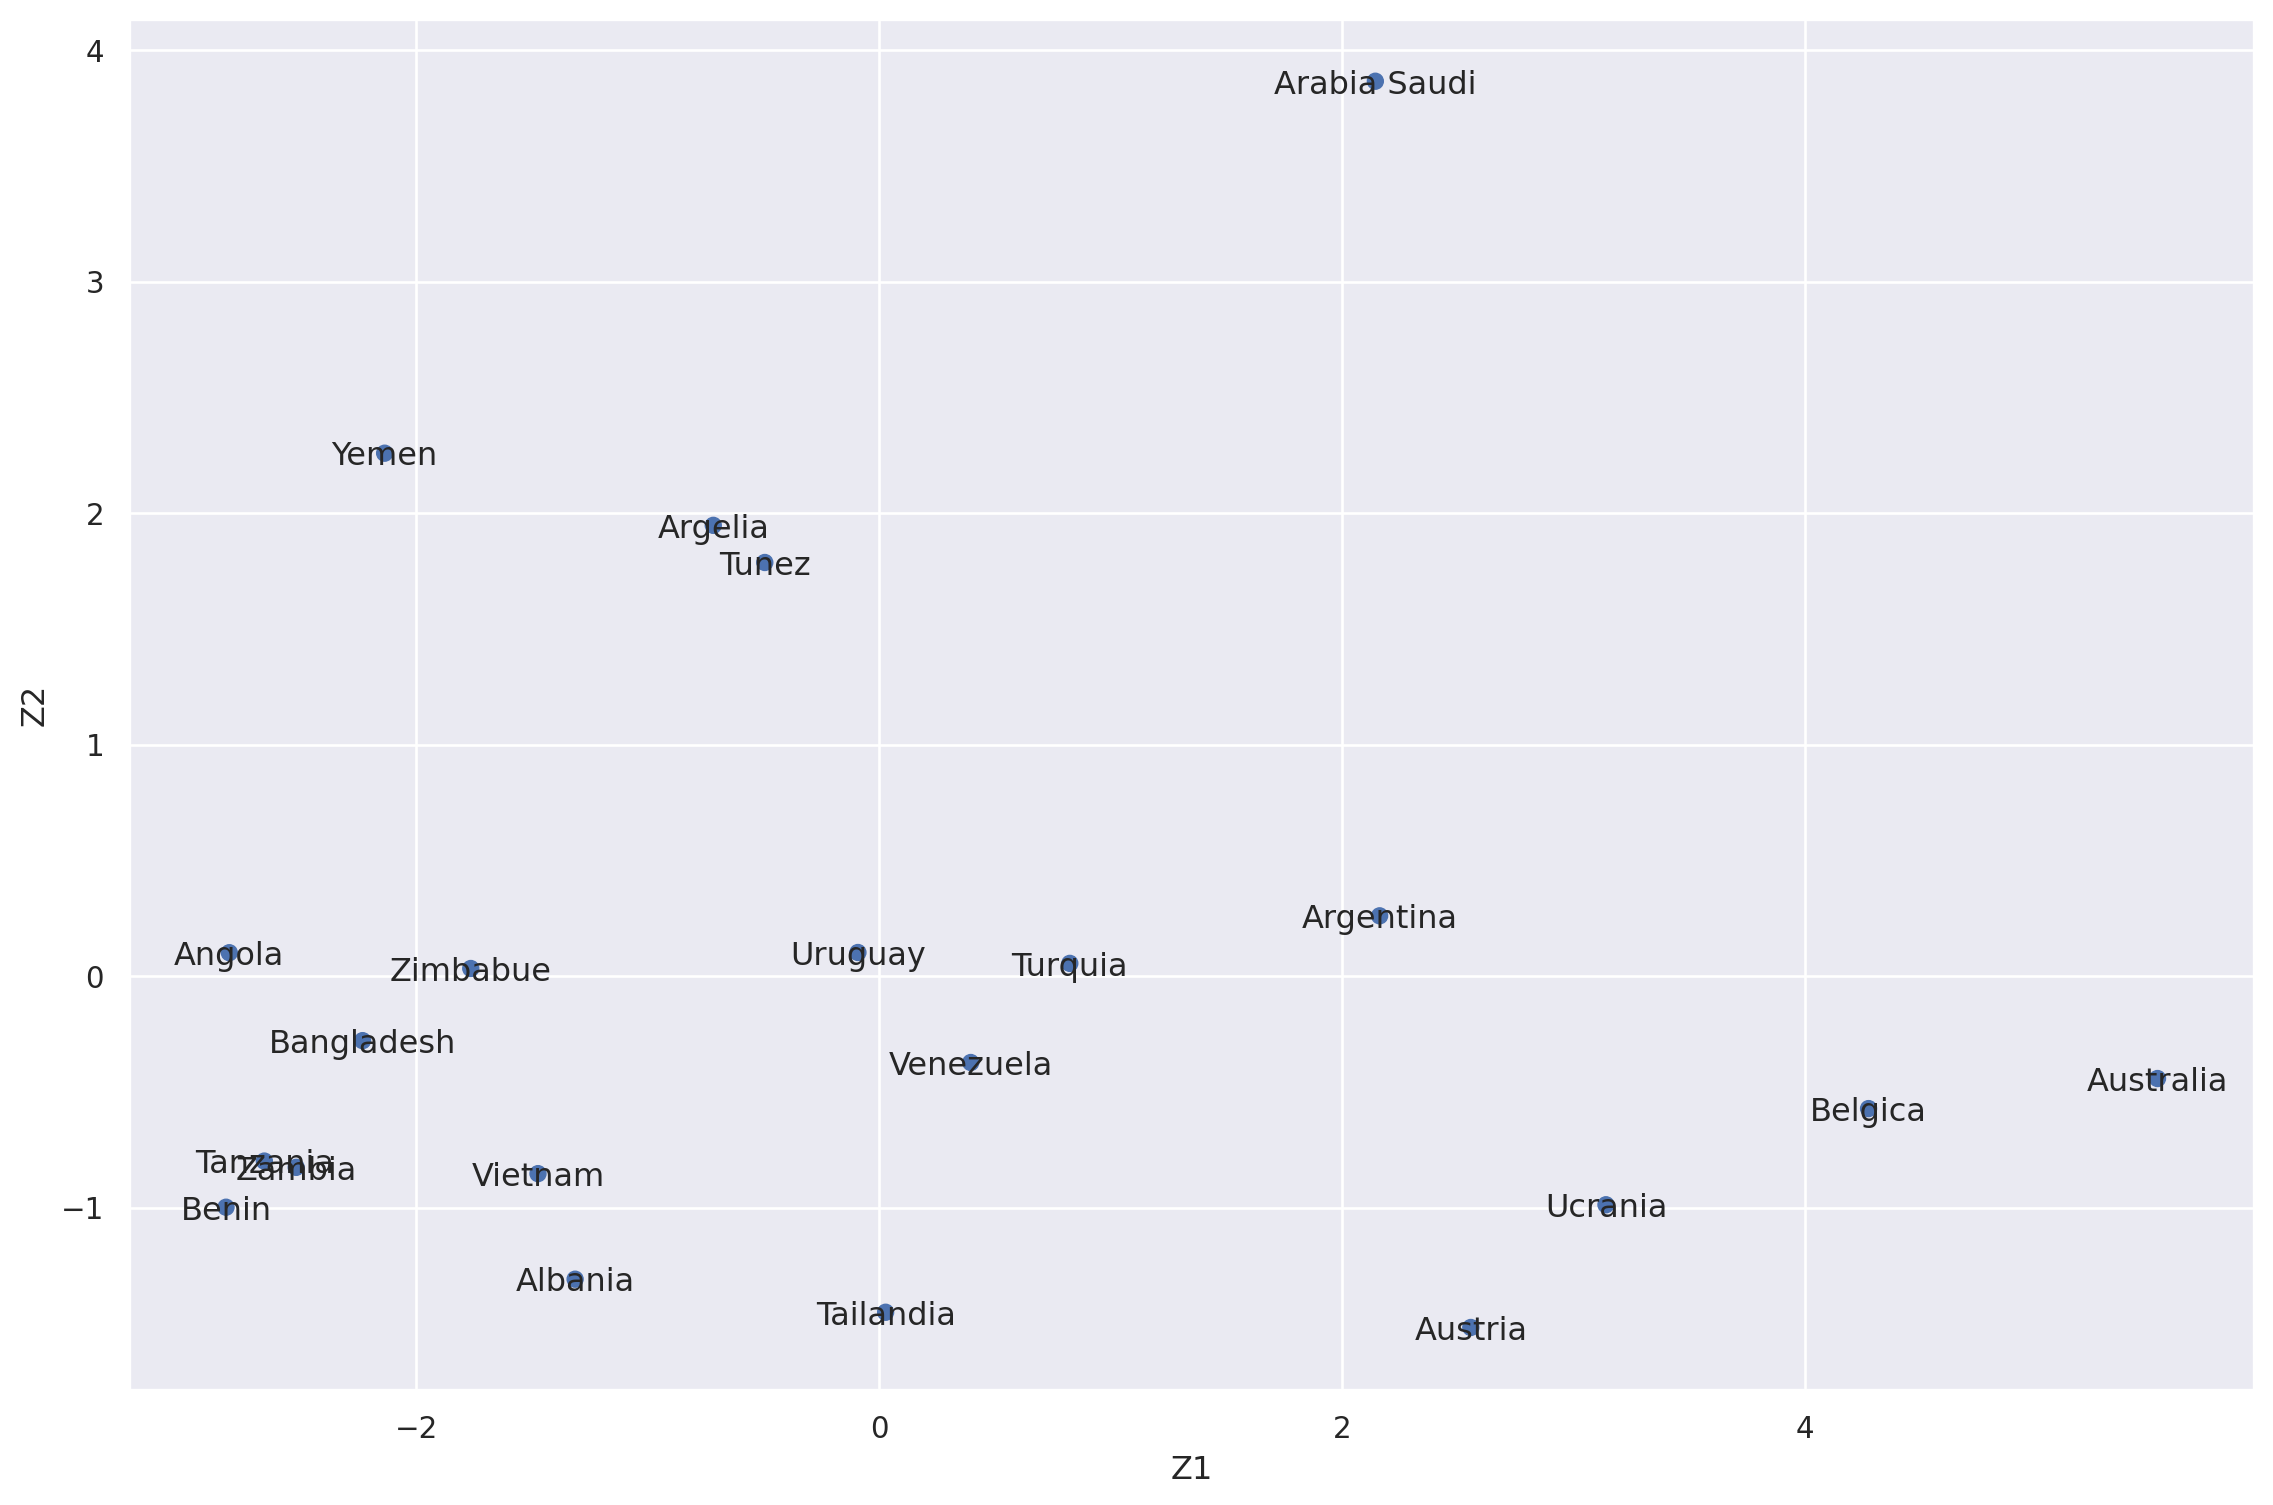

In [59]:
# Graficamos
(
    so.Plot(data = Z, x = "Z1", y = "Z2", text = X.index)
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))    
)

## PCA con sklearn

In [61]:
# Repetimos todo lo mismo usando los comandos de Python

pca = PCA(n_components=2)

principalComponents = pca.fit_transform(X_star)
print(principalComponents)

[[-1.31449773  1.30911242]
 [-2.80854116 -0.10107432]
 [ 2.14269325 -3.86532706]
 [-0.71759606 -1.94705228]
 [ 2.16123329 -0.26038045]
 [ 5.52187172  0.44233417]
 [ 2.55512467  1.51768068]
 [-2.23271035  0.27871845]
 [ 4.27357138  0.57220135]
 [-2.8227079   0.99822891]
 [ 0.02696764  1.45188755]
 [-2.65714166  0.7989188 ]
 [-0.49508675 -1.78661048]
 [ 0.82270995 -0.05498649]
 [ 3.13905426  0.98760323]
 [-0.0926372  -0.1019809 ]
 [ 0.39475798  0.37315616]
 [-1.4748402   0.85315275]
 [-2.13742482 -2.25866815]
 [-2.5194718   0.82598655]
 [-1.7653285  -0.03290091]]


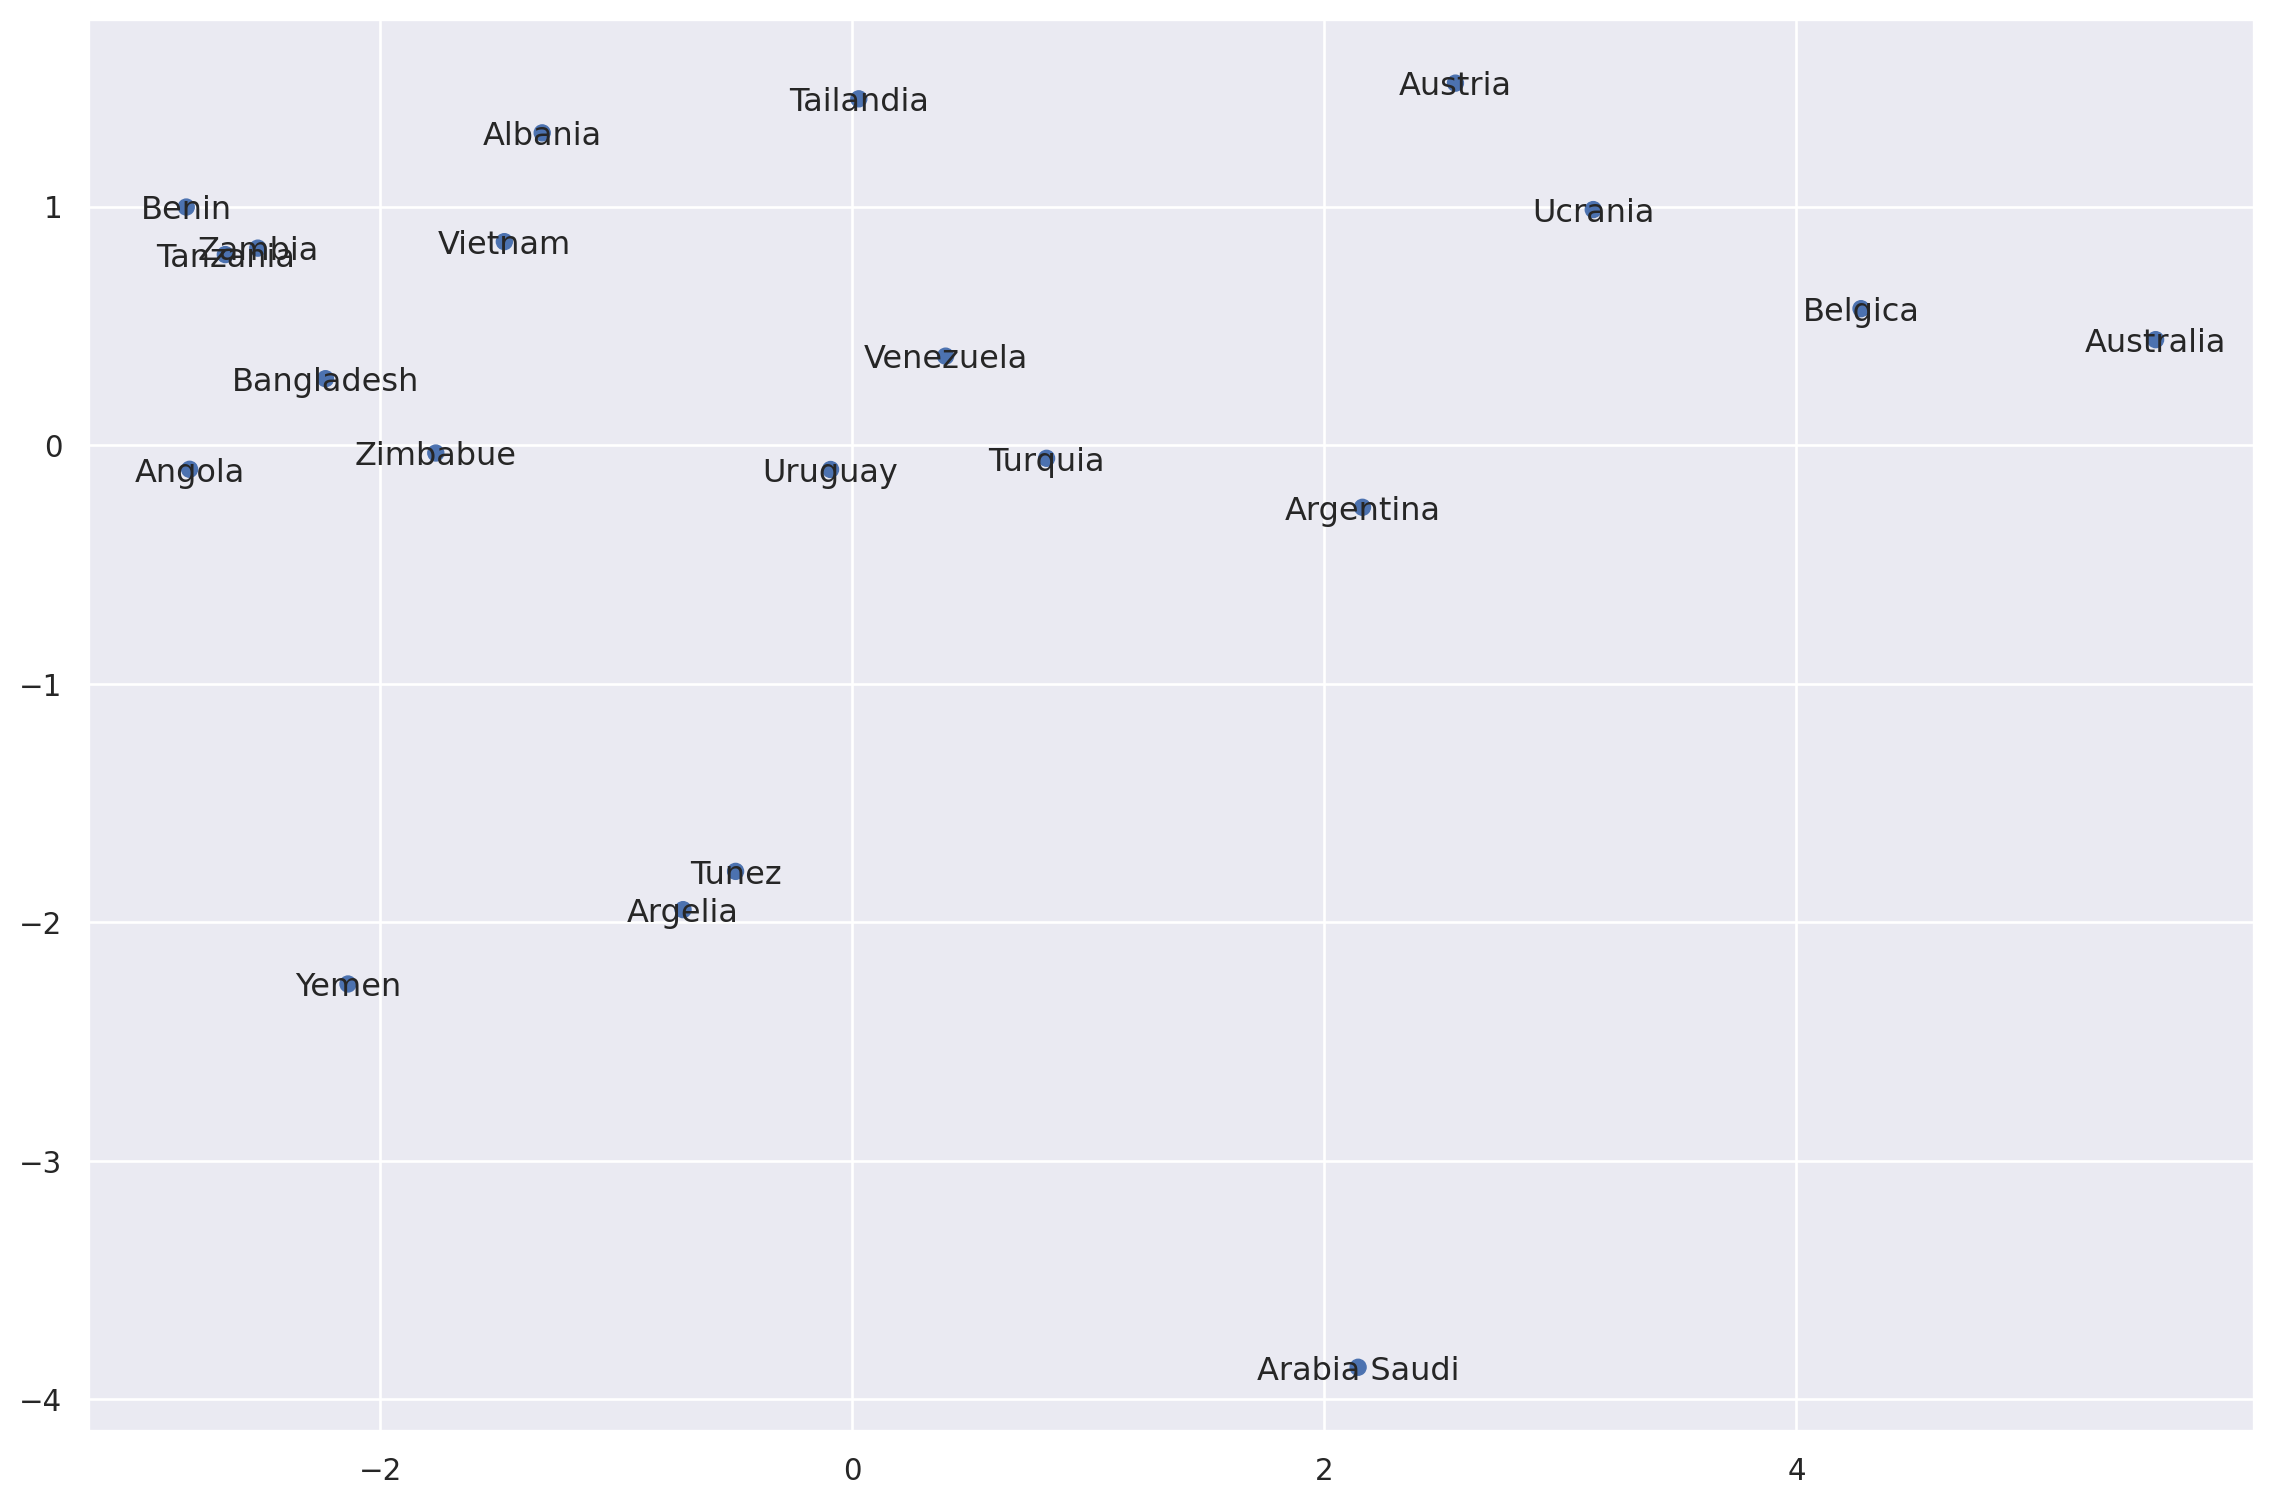

In [62]:
# Graficamos
(
    so.Plot(x = principalComponents[:,0], y = principalComponents[:,1], text = X.index)
    .add(so.Dot())
    .add(so.Text())
    .layout(size=(12,8))
)

In [63]:
# Veamos que variables aparecen más fuertemente en cada componente
pca.components_    # Esto nos da las direcciones (los coeficientes de la combinación lineal z = v_1 x_1 + ... v_p x_p)

array([[-0.229944  , -0.33938683, -0.08822039,  0.36527495,  0.34690028,
         0.36199866,  0.34936972, -0.0596501 , -0.16597822,  0.38325121,
         0.37323353],
       [-0.45216193, -0.02240731,  0.64948404,  0.0681884 ,  0.05897039,
         0.14205655, -0.01940971,  0.51723603,  0.23972876, -0.08181232,
        -0.11330387]])

In [64]:
direcciones = pd.DataFrame(pca.components_.T,  columns=["Z1", "Z2"], index=datos.columns)
direcciones["descripcion"] = col_details
direcciones

,Z1,Z2,descripcion
X1,-0.229944,-0.452162,Tasa anual de crecimiento de la población
X2,-0.339387,-0.022407,Tasa de mortalidad infantil por cada 1000 naci...
X3,-0.088220,0.649484,Porcentaje de mujeres en la población activa
X4,0.365275,0.068188,PNB en 1995 (en millones de dólares)
X5,0.346900,0.058970,Producción de electricidad (en millones kW/h)
X6,0.361999,0.142057,Líneas telefónicas por cada 1000 habitantes
X7,0.349370,-0.019410,Consumo de agua per cápita
X8,-0.059650,0.517236,Proporción de la superficie del país cubierta ...
X9,-0.165978,0.239729,Proporción de deforestación anual
X10,0.383251,-0.081812,Consumo de energía per cápita


**Pregunta** Qué interpretación podemos darle a cada una de las dos componentes?
<details>
Podemos interpetar que la primera componente agrupa las variables economicas, y la segunda componente las variable sociales.

.

El índice 1 combina básicamente todo excepto el %mujeres en pobl. activa y la proporción de bosque.
Con intensidad por encima de 0.3 tenemos 2(-),5(+),6(+),10(+), 11(+)... se trata de un índice de desarrollo (comunicaciones, electricidad, energía)...

.

El índice 2 se centra en 1-crecimiento demográfico(-), 3-mujeres activas(+) y 8 bosques(++).
Este índice es un índice más sociocultural, los de valor bajo tienen mucho crecimiento demográfico, pocas
mujeres trabajando, pocos bosques... por el contrario, los altos son poco crecimiento, muchas mujeres
trabajando, más bosques.    
</details>

**Ejercicio:** calcular el porcentaje de la varianza explicada por las primeras dos componentes principales y la varianza acumulada.

In [65]:
print("Autovalores: ", gamma)

nComps = 5
for i in range(nComps):
    print("Variaza explicada por la componente ", i + 1, ": ", gamma[i] / sum(gamma))

print("Variaza acumulada: ", gamma[:nComps].sum() / sum(gamma))

Autovalores:  [5.80179346e+00 1.80967483e+00 9.87267285e-01 7.88538421e-01
 5.55648302e-01 4.81437963e-01 3.55335107e-01 1.06712764e-01
 7.81459028e-02 3.25582148e-02 2.88774979e-03]
Variaza explicada por la componente  1 :  0.5274357693817542
Variaza explicada por la componente  2 :  0.16451589333118974
Variaza explicada por la componente  3 :  0.08975157138326179
Variaza explicada por la componente  4 :  0.07168531104175198
Variaza explicada por la componente  5 :  0.05051348199384813
Variaza acumulada:  0.9039020271318059


**Pregunta:** Si queremos explicar el 90% de la varianza en los datos, con cuántas componentes nos quedamos?

## Ejercicio

El dataset df_sports_tfidf contiene la información de que palabras aparecen en una colección de 500 articulos de noticias de deportes. 

Visualizar los artículos en el plano mediante componentes principales (en este caso las variables ya están normalizadas siguiendo una estrategia específica para palabras en textos, no hay que aplicar otra normalización).

In [94]:
df_sports_tfidf = pd.read_csv("df_sports_tfidf.csv")

In [95]:
df_sports_tfidf.head()

,aaa,aac,aaron,abandon,abat,abbott,abc,abdomen,abdomin,abeb,...,zimbabw,zinc,zinedin,zoe,zola,zone,zornotza,zuluaga,zurich,zvonareva
0,0.090412,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
df_sports_tfidf.isna().sum().max()

0

In [103]:
pca = PCA(n_components=2)

Z = pca.fit_transform(df_sports_tfidf)

In [106]:
Z = pd.DataFrame(Z)
Z.columns = ["Z1", "Z2"]
Z

,Z1,Z2
0,-0.124367,-0.031597
1,-0.020397,0.078394
2,-0.129937,-0.018403
3,-0.219956,0.139727
4,-0.119374,-0.031280
...,...,...
506,-0.043187,-0.137786
507,-0.031348,-0.107040
508,-0.026128,-0.169442
509,-0.041429,-0.105754


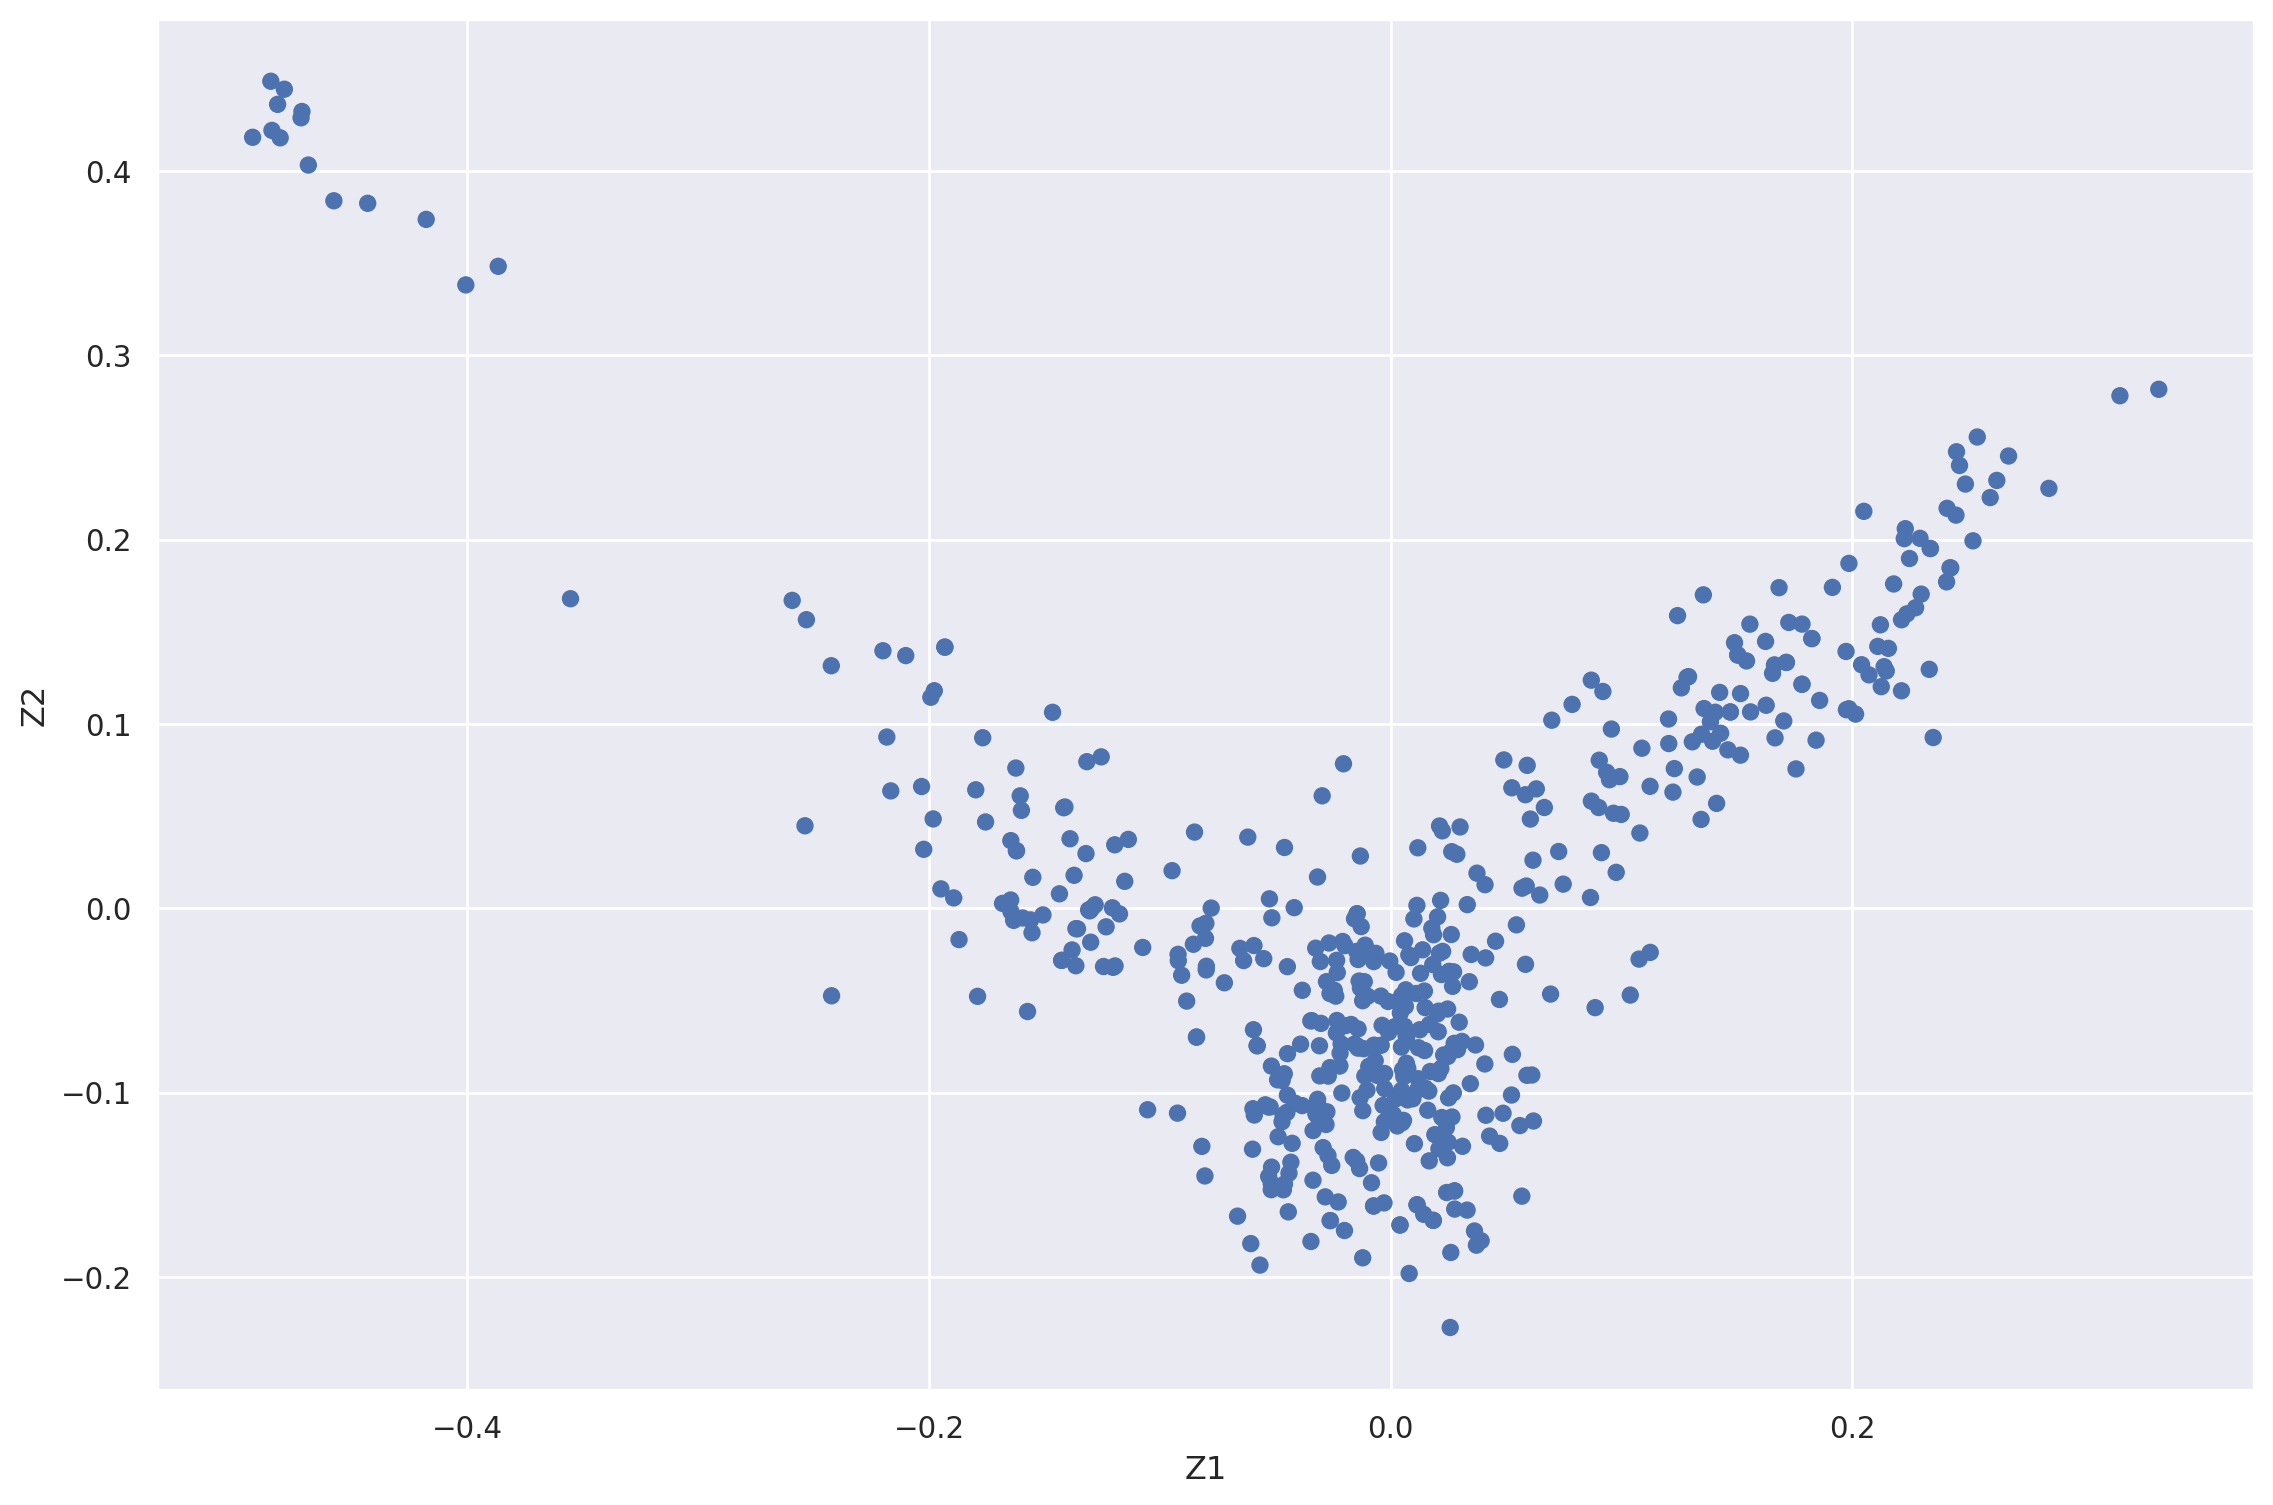

In [107]:
(
    so.Plot(data = Z, x = "Z1", y = "Z2")
    .add(so.Dot())
    .layout(size=(12,8))
)

In [93]:
direcciones = pd.DataFrame(
    pca.components_.T, 
    columns=["Z1", "Z2"], 
    index=[df_sports_tfidf.columns[i] for i in z1.sort_values(ascending=False).index]
)#df_sports_tfidf.columns)
# direcciones["dist"] = direcciones["Z1"]**2 + direcciones["Z2"]**2
direcciones[:20]

,Z1,Z2,dist
england,-0.021043,-0.003179,4.529288e-04
wale,-0.000679,0.000504,7.157385e-07
ireland,0.003027,0.002087,1.351537e-05
robinson,0.000485,-0.002809,8.126247e-06
six,-0.002443,0.000083,5.975656e-06
nation,0.008228,0.009340,1.549267e-04
franc,-0.001842,0.001646,6.105576e-06
rugbi,-0.002349,-0.000077,5.524376e-06
side,-0.000414,-0.003380,1.159760e-05
scotland,-0.001609,-0.000374,2.729697e-06


Pueden verse grupos de noticias? Analizando las palabras con mayor y menos peso en la componente Z1, ¿a qué noticias corresponden los grupos de la derecha y de la izquierda?

In [110]:
# Para ver las columnas con mayor y menos peso en la componente Z1
u1 = pd.Series(pca.components_[0])
u1

0      -0.021046
1      -0.000680
2       0.003026
3       0.000482
4      -0.002444
          ...   
7188   -0.000097
7189   -0.001493
7190   -0.000267
7191    0.011364
7192   -0.000039
Length: 7193, dtype: float64

In [111]:
# Noticias de la izquierda: coeficientes negativos mas grandes
[df_sports_tfidf.columns[i] for i in u1.sort_values().index[:10]]

['olymp',
 'athlet',
 'kenteri',
 'thanou',
 'iaaf',
 'athen',
 'greek',
 'test',
 'drug',
 'ban']

In [112]:
# Noticias de la derecha: coeficientes positivos mas grandes
[df_sports_tfidf.columns[i] for i in u1.sort_values().index[-10:]]

['scotland',
 'side',
 'rugbi',
 'franc',
 'nation',
 'six',
 'robinson',
 'ireland',
 'wale',
 'england']